## Important: Execution Order

**Please run all cells in sequential order from top to bottom.** The analysis depends on variables created in earlier cells (particularly `Term_Label`, `students_unique`, and `term_labels_ordered`).
# Exploratory Data Analysis: Student Enrollment Data (Fall 2016 - Spring 2021)

## Loyola University Chicago - College of Arts and Sciences

This notebook provides a comprehensive analysis of student enrollment patterns, demographics, academic performance, and course characteristics across multiple semesters and years.

## Data Dictionary

This analysis examines student enrollment data from Fall 2016 to Spring 2021.

### Student Identification
- **LID**: Loyola ID (student identification number)
- **Name**: Full name (anonymized)
- **Last_Name**: Student's last name
- **First_Name**: Student's first name
- **Middle_Name**: Student's middle name
- **Campus_Email**: Student's email address

### Student Demographics
- **Gender**: Student's gender
- **Ethnicity**: Student's ethnicity
- **ReligiousPreference**: Student's religious preference
- **Permanent_City**: City of permanent residence
- **Permanent_State**: State of permanent residence
- **Permanent_Zip**: Zip code of permanent residence

### Academic Standing
- **Academic_Level**: Year of study (Freshman, Sophomore, Junior, Senior, Graduate, Professional Year)
- **Career**: Program type (UGRD=Undergraduate, GRAD=Graduate, MEDS=Medical School, LAW=Law, etc.)
- **AcademicGroup**: School/college (CAS=College of Arts and Sciences, BUS=Business, ENGS=Engineering, SOC=School of Communication, etc.)
- **Program**: Program code (e.g., UCAS, UBUS, USOC, UES, MED)
- **Active_Plan_List**: Current academic plan(s)/major(s) (e.g., PSYC-BS, PLSC-BA, MGMT-BBA)
- **Active_Subplan_List**: Subplans (concentrations, tracks, minors) (e.g., BIOE-MINR, SPAN-MINR, PSCJ-MINR)
- **ProgramStatus**: Status in program (AC=Active, CM=Completed, DC=Discontinued)
- **AcademicLoad**: Full-time/part-time status (F=Full-time, H=Half-time or Part-time, L=Less than half-time)
- **AdvisorList**: Student's academic advisor(s)

### Course Information
- **Term**: Term code (format: CYYS where C=century, YY=year, S=semester)
- **SessionCode**: Session within term (1=full semester, others may be partial sessions)
- **Course_ID**: Unique course identifier
- **ClassNumber**: Class section number
- **Subject**: Subject/department code (e.g., PSYC, BIOL, MATH, PHIL, THEO, MGMT, PLSC, COMM, etc.)
- **CatalogNumber**: Course catalog number (e.g., 101, 304, 368)
- **ClassSection**: Section identifier (e.g., 001, 002, 104)
- **CourseDescription**: Course title/name
- **ComponentDescription**: Type of instruction (Lecture, Laboratory, Discussion, Seminar, etc.)

### Enrollment Details
- **EnrollmentStatus**: Current enrollment status (Enrolled, Dropped, etc.)
- **EnrollmentAdd_Date**: Date student enrolled in course
- **EnrollmentDrop_Date**: Date student dropped course (if applicable)
- **FinalGrade**: Final grade received (A, A-, B+, B, B-, C+, C, C-, D, F, W=Withdrawn, P=Pass, etc.)
- **EarnCredit**: Whether credit was earned (Y/N)
- **Units_Earned**: Credit hours earned

### Course Characteristics
- **WritingIntensive**: Whether course is writing intensive (Y/blank)
- **ExperientialLearning**: Whether course includes experiential learning (Y/blank)
- **Honors**: Whether this is an honors course (Y/blank)
- **BusinessHonors**: Whether this is a business honors course (Y/blank)
- **CORE_Area**: Core curriculum area designation (Y/N)

### Academic Performance
- **CummulativeGPA**: Student's cumulative GPA
- **TermGPA**: Student's GPA for this term
- **EnrolledCourses**: Number of courses enrolled in
- **EnrolledHours**: Total credit hours enrolled
- **DroppedHours**: Credit hours dropped
- **WithdrawnHours**: Credit hours withdrawn from
- **FailedHours**: Credit hours failed

### Instructor and Location
- **InstructorLID**: Instructor's Loyola ID
- **InstructorName**: Instructor's name
- **MeetingBuilding**: Building where class meets (e.g., CUNEO, CC, SULL, ONLINE, OTHER)
- **MeetingRoom**: Room number (e.g., 210, AUDT, GALV)
- **ClassCampus**: Campus location code (LSC=Lake Shore Campus, WTC=Water Tower Campus, LUMC=Loyola University Medical Center, ONLN=Online, etc.)
- **ClassLocation**: Campus name (Lake Shore Campus, Water Tower Campus, Medical Center Campus, Online Campus, etc.)
- **ClassStartTime**: Class start time
- **ClassEndTime**: Class end time
- **Days**: Days of week class meets (M=Monday, T=Tuesday, W=Wednesday, Th=Thursday, F=Friday, etc.)
## Load Data

Note: The data merging code at the bottom of the file is commented out as the merged file already exists.

In [48]:
# Import Required Libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [49]:
# Load the merged enrollment data
df = pd.read_csv('OneDrive_1_1-22-2026/merged_student_enrollment.tsv', sep='\t', low_memory=False)

print(f"Dataset shape: {df.shape}")
print(f"Total records: {len(df):,}")
print(f"Total unique students: {df['LID'].nunique():,}")
print(f"\nColumn names and types:")
print(df.dtypes)

Dataset shape: (811147, 74)
Total records: 811,147
Total unique students: 45,820

Column names and types:
LID                              int64
Name                            object
Last_Name                       object
First_Name                      object
Middle_Name                    float64
                                ...   
Plan_List_Start_ofTerm_1192     object
Plan_List_Start_ofTerm_1182     object
Plan_List_Start_ofTerm_1202     object
Plan_List_Start_ofTerm_1212     object
Plan_List_Start_ofTerm_1206     object
Length: 74, dtype: object


In [50]:
# Basic data overview
print("First few rows:")
print(df.head())
print("\n" + "="*80)
print("\nData Info:")
df.info()
print("\n" + "="*80)
print("\nMissing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False))

First few rows:
       LID      Name Last_Name First_Name  Middle_Name    Campus_Email  \
0  7603119  Name, No      Name         No          NaN  noname@luc.edu   
1  7603119  Name, No      Name         No          NaN  noname@luc.edu   
2  7998427  Name, No      Name         No          NaN  noname@luc.edu   
3  7962128  Name, No      Name         No          NaN  noname@luc.edu   
4  7962128  Name, No      Name         No          NaN  noname@luc.edu   

        Academic_Level Career AcademicGroup Program  ... CORE_Area  \
0             Graduate   GRAD           CAS    GA&S  ...         N   
1             Graduate   GRAD           CAS    GA&S  ...         N   
2  Professional Year 1   MEDS           MED     MED  ...         N   
3             Freshman   UGRD           CAS    UCAS  ...         N   
4             Freshman   UGRD           CAS    UCAS  ...         N   

  Plan_List_Start_ofTerm_1176 Plan_List_Start_ofTerm_1172  \
0                         NaN                         NaN

## 1. Temporal Analysis: Enrollment Trends Over Time

In [51]:
# Parse term codes - format is CYYS where C=century, YY=year, S=semester
# 1166 = 2016 Fall (semester 6), 1172 = 2017 Spring (semester 2)
def parse_term(term):
    """Parse term code to get year and semester"""
    term_str = str(term)
    if len(term_str) == 4:
        year = 2000 + int(term_str[1:3])
        sem_code = term_str[3]
        semester = 'Spring' if sem_code == '2' else 'Fall' if sem_code == '6' else 'Unknown'
        return year, semester, f"{semester} {year}"
    return None, None, None

df['Year'], df['Semester'], df['Term_Label'] = zip(*df['Term'].apply(parse_term))

# Create term order for chronological sorting
term_order = df.groupby(['Year', 'Semester', 'Term_Label'])['Term'].first().sort_values()
df['Term_Order'] = df['Term'].map({term: idx for idx, term in enumerate(term_order.values)})

print("Terms in dataset:")
print(df.groupby(['Term', 'Term_Label']).size().sort_index())

Terms in dataset:
Term  Term_Label 
1166  Fall 2016      81275
1172  Spring 2017    74214
1176  Fall 2017      83040
1182  Spring 2018    75367
1186  Fall 2018      86187
1192  Spring 2019    78549
1196  Fall 2019      87841
1202  Spring 2020    79868
1206  Fall 2020      86568
1212  Spring 2021    78238
dtype: int64


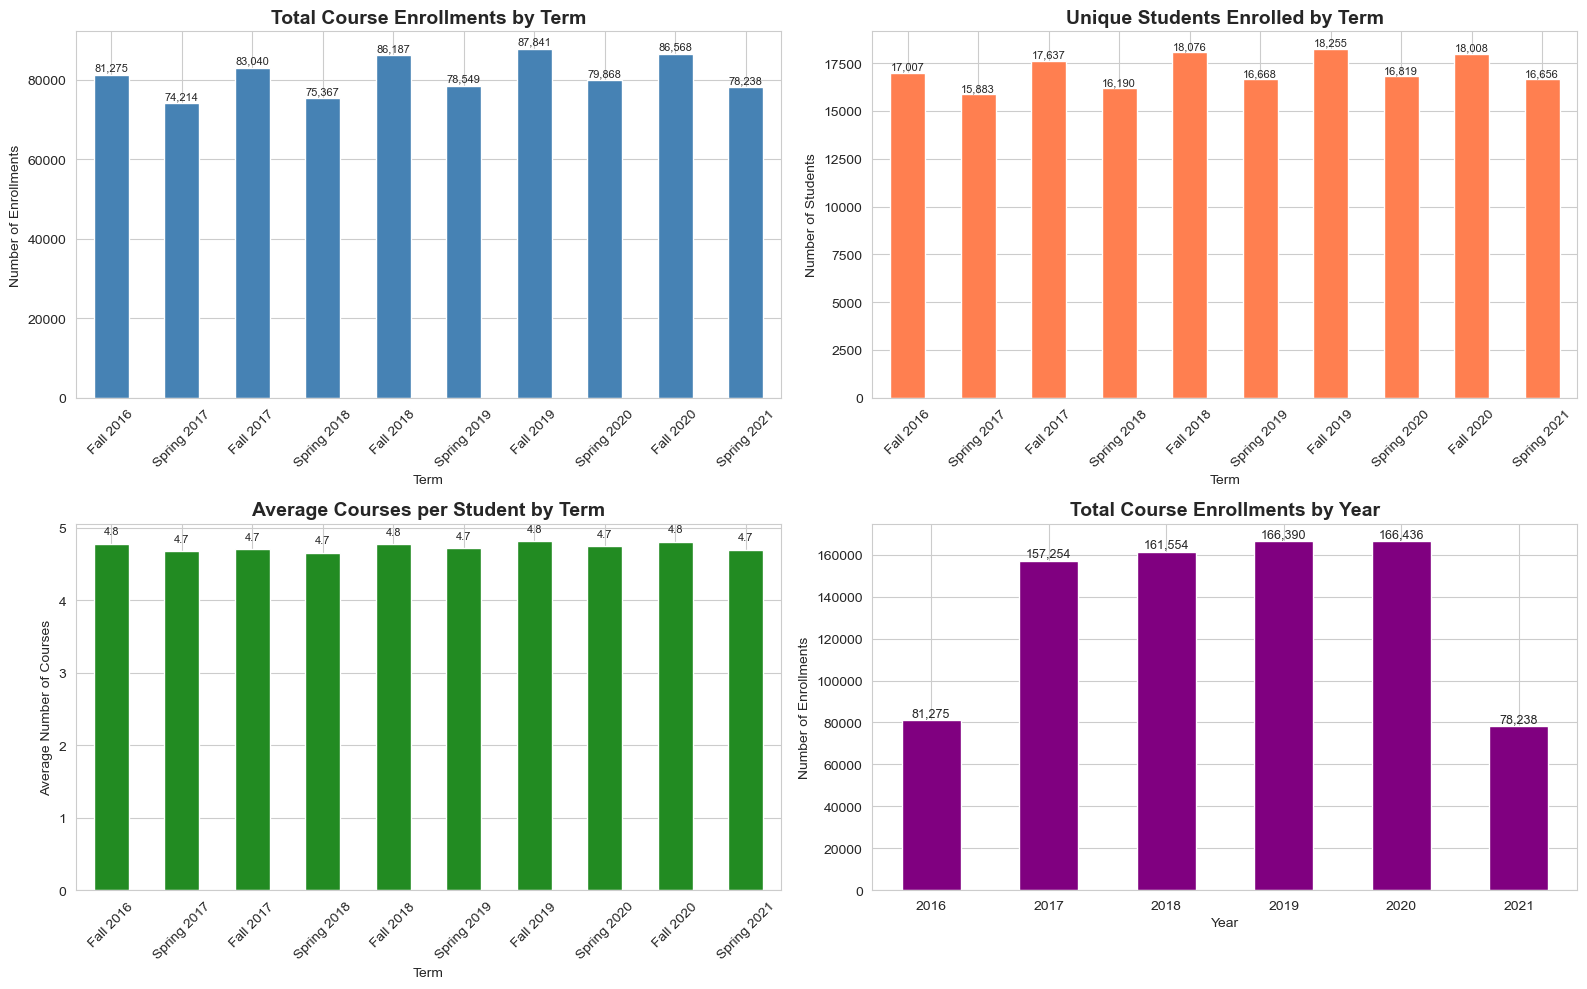


Enrollment Summary by Term:
             Total Enrollments  Unique Students  Avg Courses/Student
Term_Label                                                          
Fall 2016                81275            17007             4.778915
Spring 2017              74214            15883             4.672543
Fall 2017                83040            17637             4.708284
Spring 2018              75367            16190             4.655158
Fall 2018                86187            18076             4.768035
Spring 2019              78549            16668             4.712563
Fall 2019                87841            18255             4.811887
Spring 2020              79868            16819             4.748677
Fall 2020                86568            18008             4.807197
Spring 2021              78238            16656             4.697286


In [52]:
# Enrollment trends by term
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Total enrollments per term
term_enrollments = df.groupby('Term_Label').size().reindex(
    df.sort_values('Term_Order')['Term_Label'].unique()
)
ax1 = axes[0, 0]
term_enrollments.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Total Course Enrollments by Term', fontsize=14, fontweight='bold')
ax1.set_xlabel('Term')
ax1.set_ylabel('Number of Enrollments')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(term_enrollments):
    ax1.text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontsize=8)

# 2. Unique students per term
students_per_term = df.groupby('Term_Label')['LID'].nunique().reindex(
    df.sort_values('Term_Order')['Term_Label'].unique()
)
ax2 = axes[0, 1]
students_per_term.plot(kind='bar', ax=ax2, color='coral')
ax2.set_title('Unique Students Enrolled by Term', fontsize=14, fontweight='bold')
ax2.set_xlabel('Term')
ax2.set_ylabel('Number of Students')
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(students_per_term):
    ax2.text(i, v + 50, f'{v:,}', ha='center', va='bottom', fontsize=8)

# 3. Average courses per student by term
avg_courses = (term_enrollments / students_per_term).fillna(0)
ax3 = axes[1, 0]
avg_courses.plot(kind='bar', ax=ax3, color='forestgreen')
ax3.set_title('Average Courses per Student by Term', fontsize=14, fontweight='bold')
ax3.set_xlabel('Term')
ax3.set_ylabel('Average Number of Courses')
ax3.tick_params(axis='x', rotation=45)
for i, v in enumerate(avg_courses):
    ax3.text(i, v + 0.1, f'{v:.1f}', ha='center', va='bottom', fontsize=8)

# 4. Enrollment by year
yearly_enrollments = df.groupby('Year').size()
ax4 = axes[1, 1]
yearly_enrollments.plot(kind='bar', ax=ax4, color='purple')
ax4.set_title('Total Course Enrollments by Year', fontsize=14, fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Number of Enrollments')
ax4.tick_params(axis='x', rotation=0)
for i, v in enumerate(yearly_enrollments):
    ax4.text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nEnrollment Summary by Term:")
summary = pd.DataFrame({
    'Total Enrollments': term_enrollments,
    'Unique Students': students_per_term,
    'Avg Courses/Student': avg_courses
})
print(summary)

## 3. Academic Standing Analysis

In [53]:
# Academic level distribution
print("Academic Level Distribution (all enrollments):")
print(df['Academic_Level'].value_counts())
print("\n" + "="*60)

print("\nCareer Distribution:")
print(df['Career'].value_counts())
print("\n" + "="*60)

print("\nAcademic Group Distribution:")
print(df['AcademicGroup'].value_counts())
print("\n" + "="*60)

print("\nProgram Distribution:")
print(df['Program'].value_counts())
print("\n" + "="*60)

print("\nAcademic Load Distribution:")
print(df['AcademicLoad'].value_counts())

Academic Level Distribution (all enrollments):
Academic_Level
Freshman                   192192
Senior                     171788
Sophomore                  154120
Junior                     148484
Graduate                    89228
Professional Year 1         25256
Professional Year 2         16201
Professional Year 3          9231
Post-Bacc Undergraduate      2473
Professional Year 4          2174
Name: count, dtype: int64


Career Distribution:
Career
UGRD    655085
GRAD     83382
LAW      38244
ARRU     13972
BUSN     13883
MEDS      6581
Name: count, dtype: int64


Academic Group Distribution:
AcademicGroup
CAS     404096
BUS     122478
NURS     72493
LAW      46281
SOC      41192
SSW      29194
EDUC     26045
IES      18778
ARR      13972
SPS      10596
HSPH      8300
MED       6581
ENGS      5818
IPS       4257
STJO       835
DUAL       231
Name: count, dtype: int64


Program Distribution:
Program
UCAS    375338
UBUS    108595
UNRS     65490
USOC     39709
LAWD     33012
GA&S    

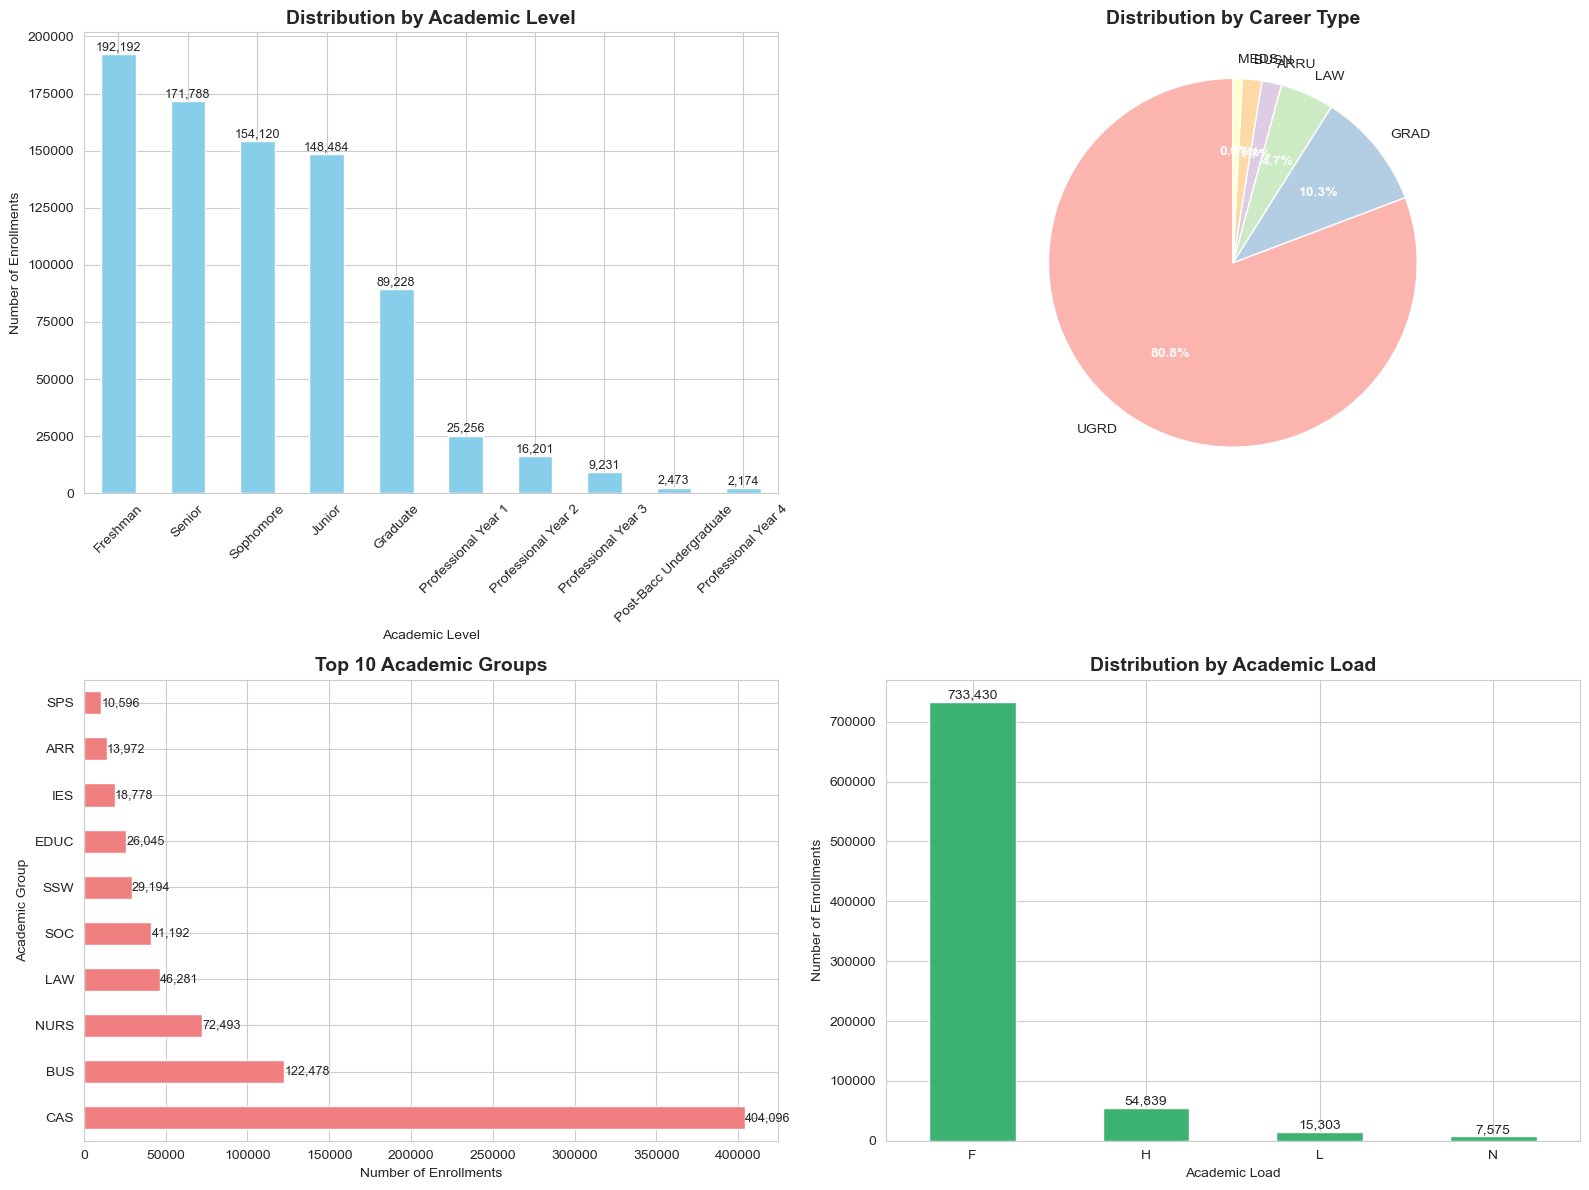

In [54]:
# Visualize academic standing
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Academic Level
academic_level = df['Academic_Level'].value_counts()
ax1 = axes[0, 0]
academic_level.plot(kind='bar', ax=ax1, color='skyblue')
ax1.set_title('Distribution by Academic Level', fontsize=14, fontweight='bold')
ax1.set_xlabel('Academic Level')
ax1.set_ylabel('Number of Enrollments')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(academic_level):
    ax1.text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontsize=9)

# 2. Career distribution
career = df['Career'].value_counts()
ax2 = axes[0, 1]
colors = sns.color_palette("Pastel1", len(career))
wedges, texts, autotexts = ax2.pie(career, labels=career.index, autopct='%1.1f%%',
                                     colors=colors, startangle=90)
ax2.set_title('Distribution by Career Type', fontsize=14, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 3. Academic Group
academic_group = df['AcademicGroup'].value_counts().head(10)
ax3 = axes[1, 0]
academic_group.plot(kind='barh', ax=ax3, color='lightcoral')
ax3.set_title('Top 10 Academic Groups', fontsize=14, fontweight='bold')
ax3.set_xlabel('Number of Enrollments')
ax3.set_ylabel('Academic Group')
for i, v in enumerate(academic_group):
    ax3.text(v + 200, i, f'{v:,}', va='center', fontsize=9)

# 4. Academic Load
academic_load = df['AcademicLoad'].value_counts()
ax4 = axes[1, 1]
academic_load.plot(kind='bar', ax=ax4, color='mediumseagreen')
ax4.set_title('Distribution by Academic Load', fontsize=14, fontweight='bold')
ax4.set_xlabel('Academic Load')
ax4.set_ylabel('Number of Enrollments')
ax4.tick_params(axis='x', rotation=0)
for i, v in enumerate(academic_load):
    ax4.text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Academic Standing Over Time

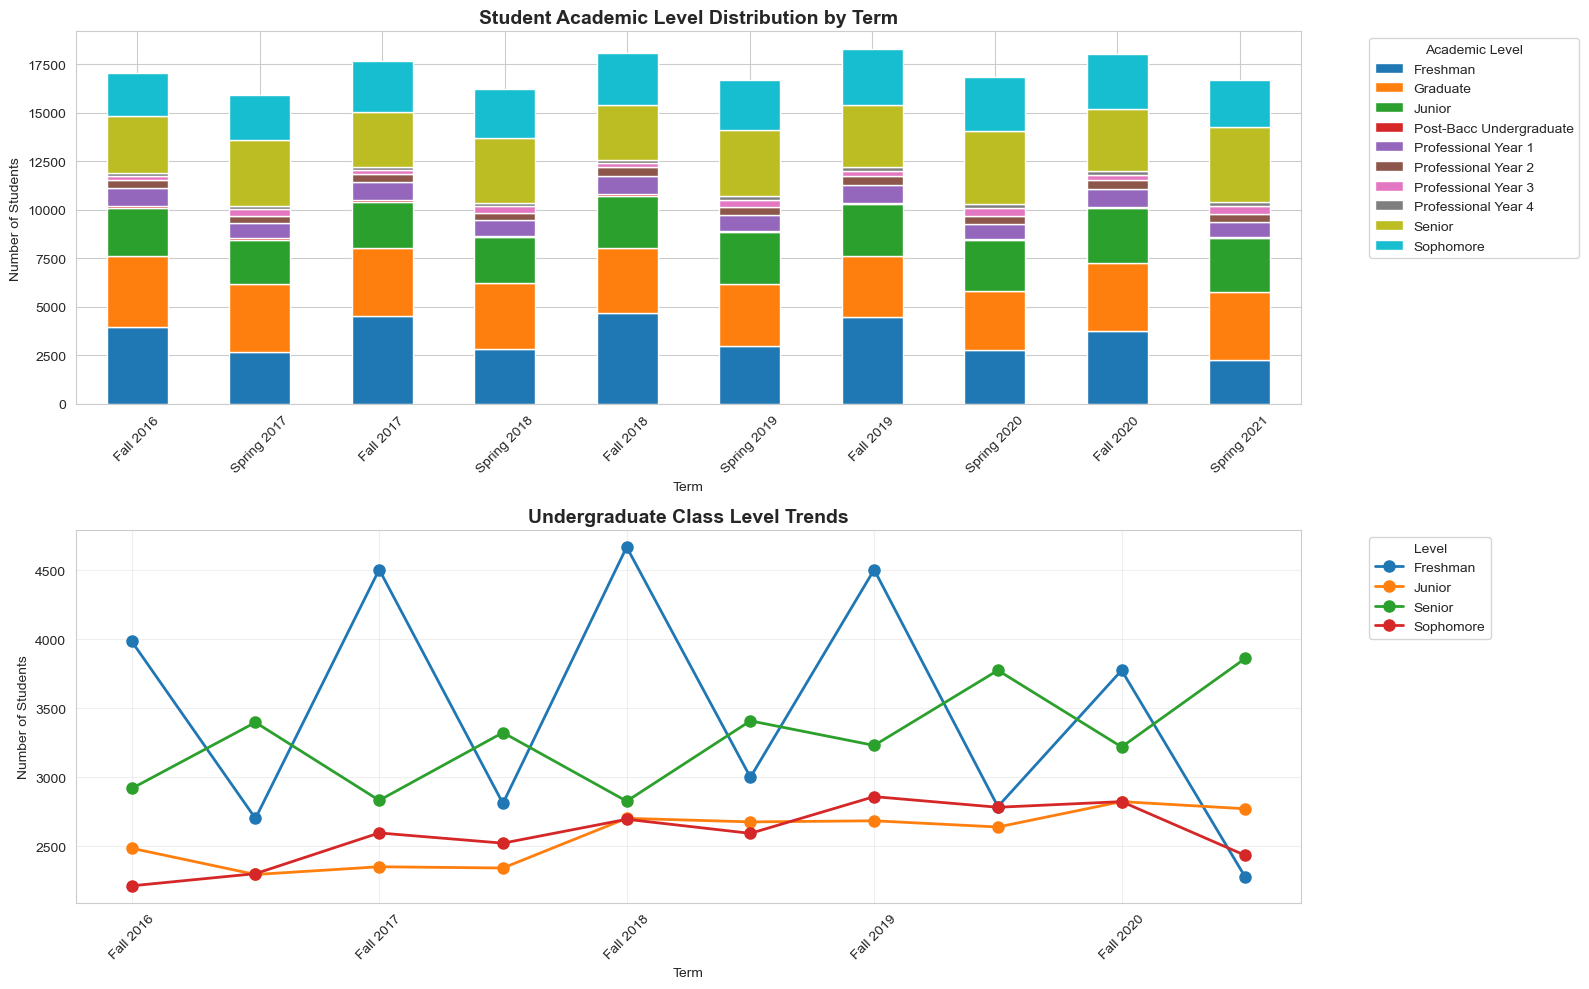


Academic Level by Term:
Academic_Level  Freshman  Graduate  Junior  Post-Bacc Undergraduate  \
Term_Label                                                            
Fall 2016           3986      3643    2487                       81   
Spring 2017         2703      3468    2297                       77   
Fall 2017           4506      3545    2353                       80   
Spring 2018         2812      3435    2344                       77   
Fall 2018           4669      3351    2704                       70   
Spring 2019         3001      3200    2678                       54   
Fall 2019           4505      3102    2686                       44   
Spring 2020         2789      3013    2641                       47   
Fall 2020           3776      3468    2825                       72   
Spring 2021         2277      3488    2773                       74   

Academic_Level  Professional Year 1  Professional Year 2  Professional Year 3  \
Term_Label                               

In [55]:
# Academic level progression over time
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 1. Academic level by term
level_by_term = df.groupby(['Term_Label', 'Academic_Level'])['LID'].nunique().unstack(fill_value=0)
term_labels_ordered = df.sort_values('Term_Order')['Term_Label'].unique()
level_by_term = level_by_term.reindex(term_labels_ordered)

ax1 = axes[0]
level_by_term.plot(kind='bar', stacked=True, ax=ax1, colormap='tab10')
ax1.set_title('Student Academic Level Distribution by Term', fontsize=14, fontweight='bold')
ax1.set_xlabel('Term')
ax1.set_ylabel('Number of Students')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Academic Level', bbox_to_anchor=(1.05, 1), loc='upper left')

# 2. Undergraduate levels trend
undergrad_levels = ['Freshman', 'Sophomore', 'Junior', 'Senior']
undergrad_by_term = level_by_term[[col for col in level_by_term.columns if col in undergrad_levels]]

ax2 = axes[1]
undergrad_by_term.plot(kind='line', ax=ax2, marker='o', linewidth=2, markersize=8)
ax2.set_title('Undergraduate Class Level Trends', fontsize=14, fontweight='bold')
ax2.set_xlabel('Term')
ax2.set_ylabel('Number of Students')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Level', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAcademic Level by Term:")
print(level_by_term)

## 4. Course Enrollment Patterns

In [56]:
# Most popular subjects
print("Top 20 Most Popular Subjects (by enrollment count):")
top_subjects = df['Subject'].value_counts().head(20)
print(top_subjects)
print("\n" + "="*60)

# Most popular courses
df['Course'] = df['Subject'] + ' ' + df['CatalogNumber'].astype(str)
print("\nTop 20 Most Popular Courses:")
top_courses = df['Course'].value_counts().head(20)
print(top_courses)

Top 20 Most Popular Subjects (by enrollment count):
Subject
BIOL    56563
CHEM    55661
LAW     45174
PHIL    32374
PSYC    31740
GNUR    30881
COMM    27904
THEO    27468
HIST    26390
MATH    25765
SOWK    21854
PHYS    20396
UNIV    17723
PLSC    14670
COMP    13609
ENGL    13437
MGMT    13149
SOCL    12588
ENVS    12151
UCLR    11787
Name: count, dtype: int64


Top 20 Most Popular Courses:
Course
UNIV 101    13227
PHIL 130    11199
UCWR 110    10376
CHEM 101     9553
BIOL 101     8815
PHIL 181     6868
THEO 100     6738
CHEM 102     6666
HIST 102     6373
CHEM 223     6250
BIOL 102     6033
UCSF 137     5878
SOCL 101     5803
MATH 131     5724
UCLR 100     5720
PHYS 111     5568
BIOL 111     5446
BIOL 251     5309
PHYS 112     5170
PSYC 101     5127
Name: count, dtype: int64


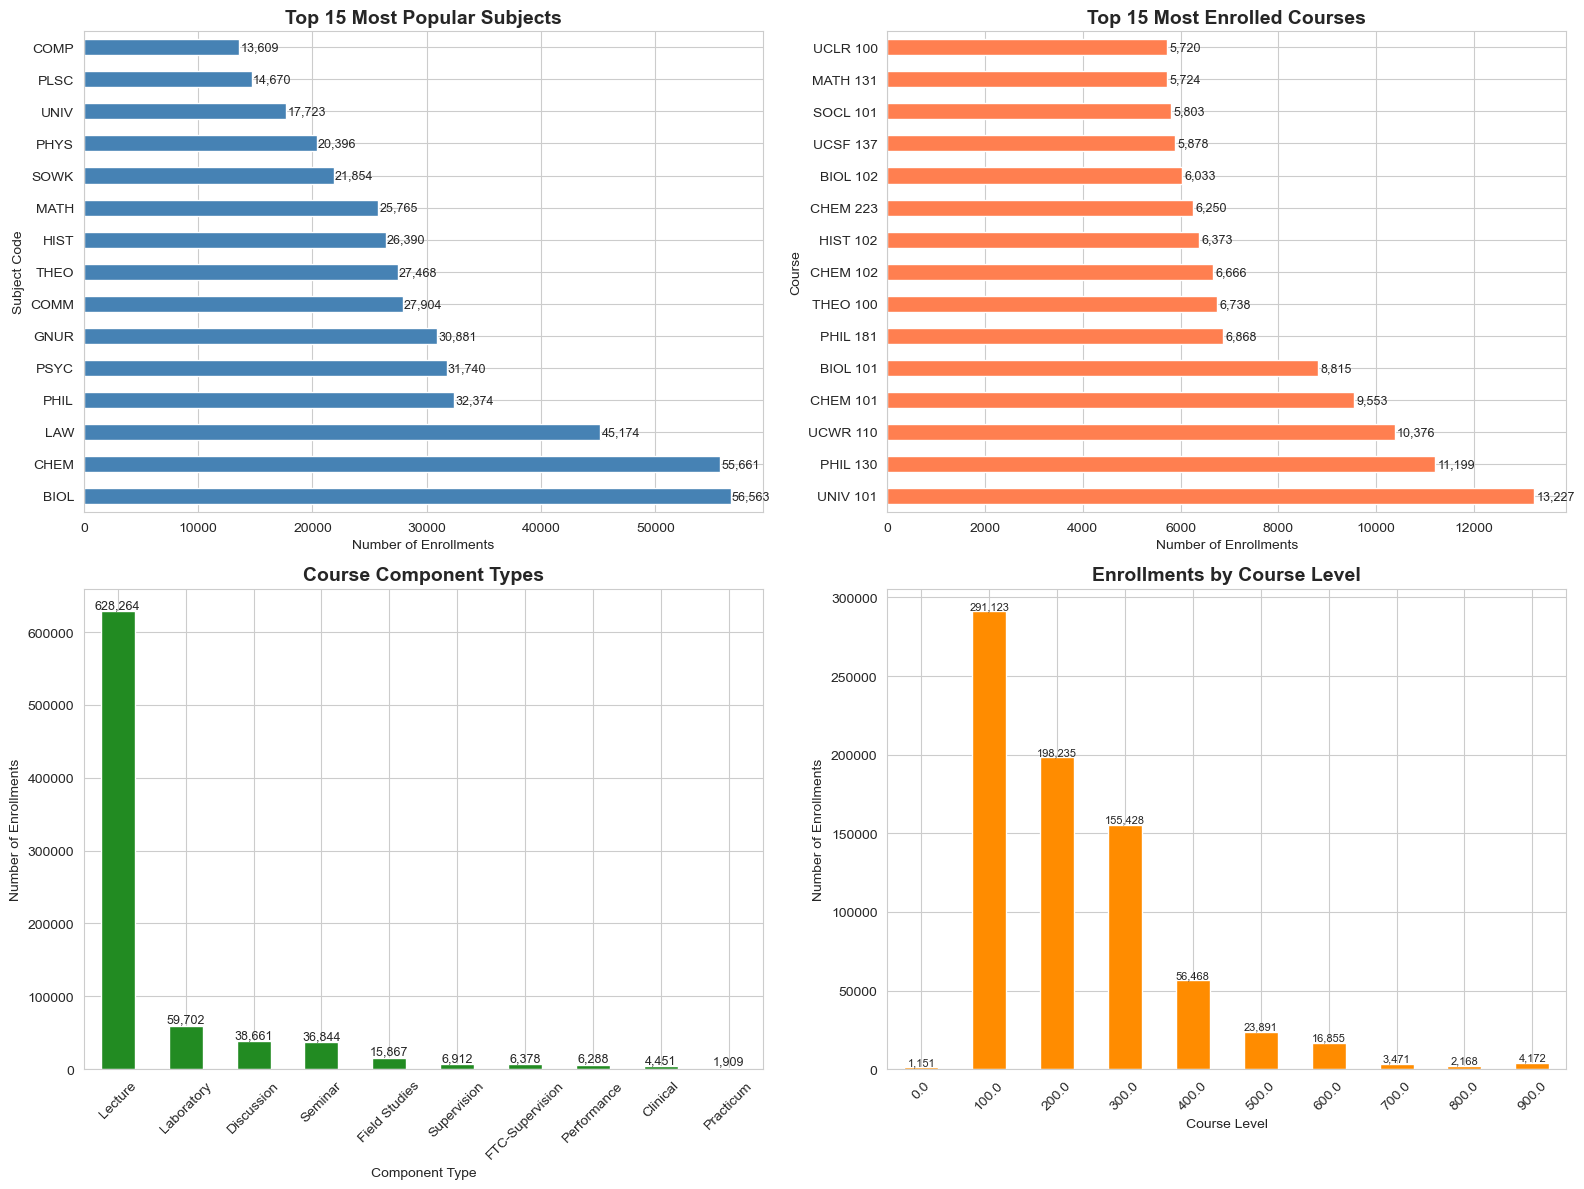

In [57]:
# Visualize course patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 15 subjects
top_subjects_15 = df['Subject'].value_counts().head(15)
ax1 = axes[0, 0]
top_subjects_15.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Top 15 Most Popular Subjects', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Enrollments')
ax1.set_ylabel('Subject Code')
for i, v in enumerate(top_subjects_15):
    ax1.text(v + 100, i, f'{v:,}', va='center', fontsize=9)

# 2. Top 15 individual courses
top_courses_15 = df['Course'].value_counts().head(15)
ax2 = axes[0, 1]
top_courses_15.plot(kind='barh', ax=ax2, color='coral')
ax2.set_title('Top 15 Most Enrolled Courses', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Enrollments')
ax2.set_ylabel('Course')
for i, v in enumerate(top_courses_15):
    ax2.text(v + 50, i, f'{v:,}', va='center', fontsize=9)

# 3. Component types
component_counts = df['ComponentDescription'].value_counts().head(10)
ax3 = axes[1, 0]
component_counts.plot(kind='bar', ax=ax3, color='forestgreen')
ax3.set_title('Course Component Types', fontsize=14, fontweight='bold')
ax3.set_xlabel('Component Type')
ax3.set_ylabel('Number of Enrollments')
ax3.tick_params(axis='x', rotation=45)
for i, v in enumerate(component_counts):
    ax3.text(i, v + 200, f'{v:,}', ha='center', va='bottom', fontsize=9)

# 4. Course levels (100, 200, 300, etc.)
df['Course_Level'] = pd.to_numeric(df['CatalogNumber'], errors='coerce').apply(
    lambda x: int((x // 100) * 100) if pd.notnull(x) else np.nan
)
course_level_counts = df['Course_Level'].value_counts().sort_index()
ax4 = axes[1, 1]
course_level_counts.plot(kind='bar', ax=ax4, color='darkorange')
ax4.set_title('Enrollments by Course Level', fontsize=14, fontweight='bold')
ax4.set_xlabel('Course Level')
ax4.set_ylabel('Number of Enrollments')
ax4.tick_params(axis='x', rotation=45)
for i, v in enumerate(course_level_counts):
    ax4.text(i, v + 200, f'{v:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### Subject Popularity Over Time

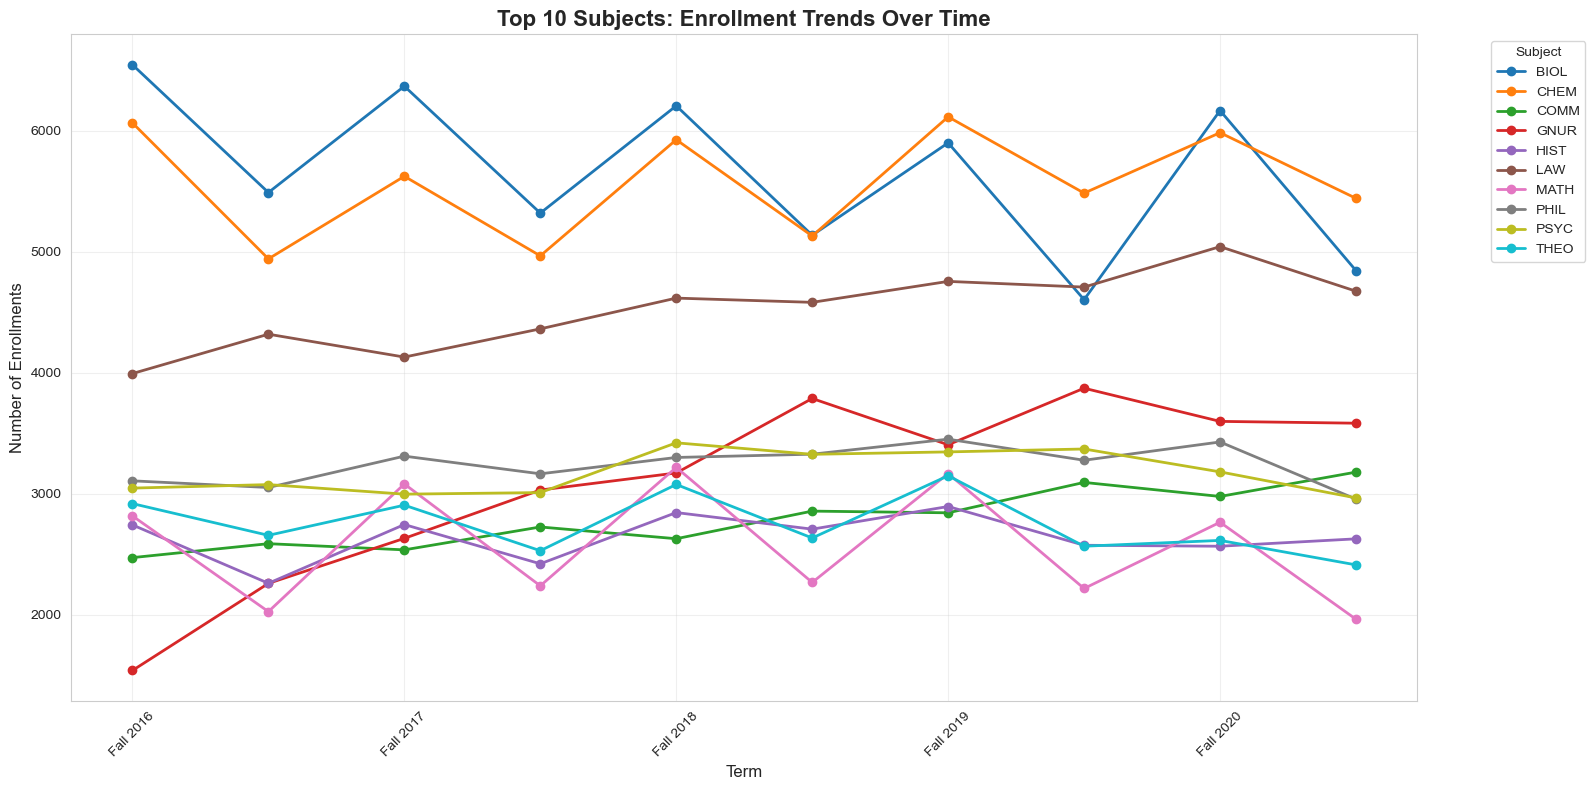


Subject enrollments by term:
Subject      BIOL  CHEM  COMM  GNUR  HIST   LAW  MATH  PHIL  PSYC  THEO
Term_Label                                                             
Fall 2016    6543  6063  2473  1541  2743  3993  2817  3107  3047  2919
Spring 2017  5488  4940  2588  2260  2261  4318  2027  3052  3076  2657
Fall 2017    6366  5622  2537  2632  2746  4129  3081  3311  2997  2906
Spring 2018  5318  4965  2726  3031  2422  4362  2240  3165  3010  2530
Fall 2018    6204  5924  2629  3172  2845  4616  3218  3300  3421  3077
Spring 2019  5135  5129  2857  3787  2708  4581  2268  3327  3326  2635
Fall 2019    5898  6113  2843  3405  2895  4754  3167  3451  3346  3149
Spring 2020  4603  5483  3094  3872  2575  4707  2218  3277  3370  2567
Fall 2020    6165  5982  2978  3598  2567  5041  2765  3428  3181  2615
Spring 2021  4843  5440  3179  3583  2628  4673  1964  2956  2966  2413


In [58]:
# Track top subjects over time
top_10_subjects = df['Subject'].value_counts().head(10).index
subject_by_term = df[df['Subject'].isin(top_10_subjects)].groupby(['Term_Label', 'Subject']).size().unstack(fill_value=0)
subject_by_term = subject_by_term.reindex(term_labels_ordered)

fig, ax = plt.subplots(figsize=(16, 8))
subject_by_term.plot(kind='line', ax=ax, marker='o', linewidth=2, markersize=6)
ax.set_title('Top 10 Subjects: Enrollment Trends Over Time', fontsize=16, fontweight='bold')
ax.set_xlabel('Term', fontsize=12)
ax.set_ylabel('Number of Enrollments', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Subject', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSubject enrollments by term:")
print(subject_by_term)

## 5. Academic Performance Analysis

In [59]:
# Grade distribution
print("Final Grade Distribution:")
grade_dist = df['FinalGrade'].value_counts()
print(grade_dist)
print("\n" + "="*60)

# GPA statistics
print("\nCumulative GPA Statistics:")
print(df['CummulativeGPA'].describe())
print("\n" + "="*60)

print("\nTerm GPA Statistics:")
print(df['TermGPA'].describe())

Final Grade Distribution:
FinalGrade
A     293156
A-    107768
B      76222
B+     75699
P      57583
B-     36744
W      25399
C      24143
C+     24024
C-     12187
F      11007
D       6761
D+      3353
NP      1149
NR       525
WF       424
AU       256
S        168
I        125
NC         1
Name: count, dtype: int64


Cumulative GPA Statistics:
count    811147.000000
mean          3.281339
std           0.674899
min           0.000000
25%           3.021000
50%           3.432000
75%           3.741000
max           4.000000
Name: CummulativeGPA, dtype: float64


Term GPA Statistics:
count    811147.000000
mean          3.260364
std           0.864949
min           0.000000
25%           3.002000
50%           3.511000
75%           3.835000
max           4.000000
Name: TermGPA, dtype: float64


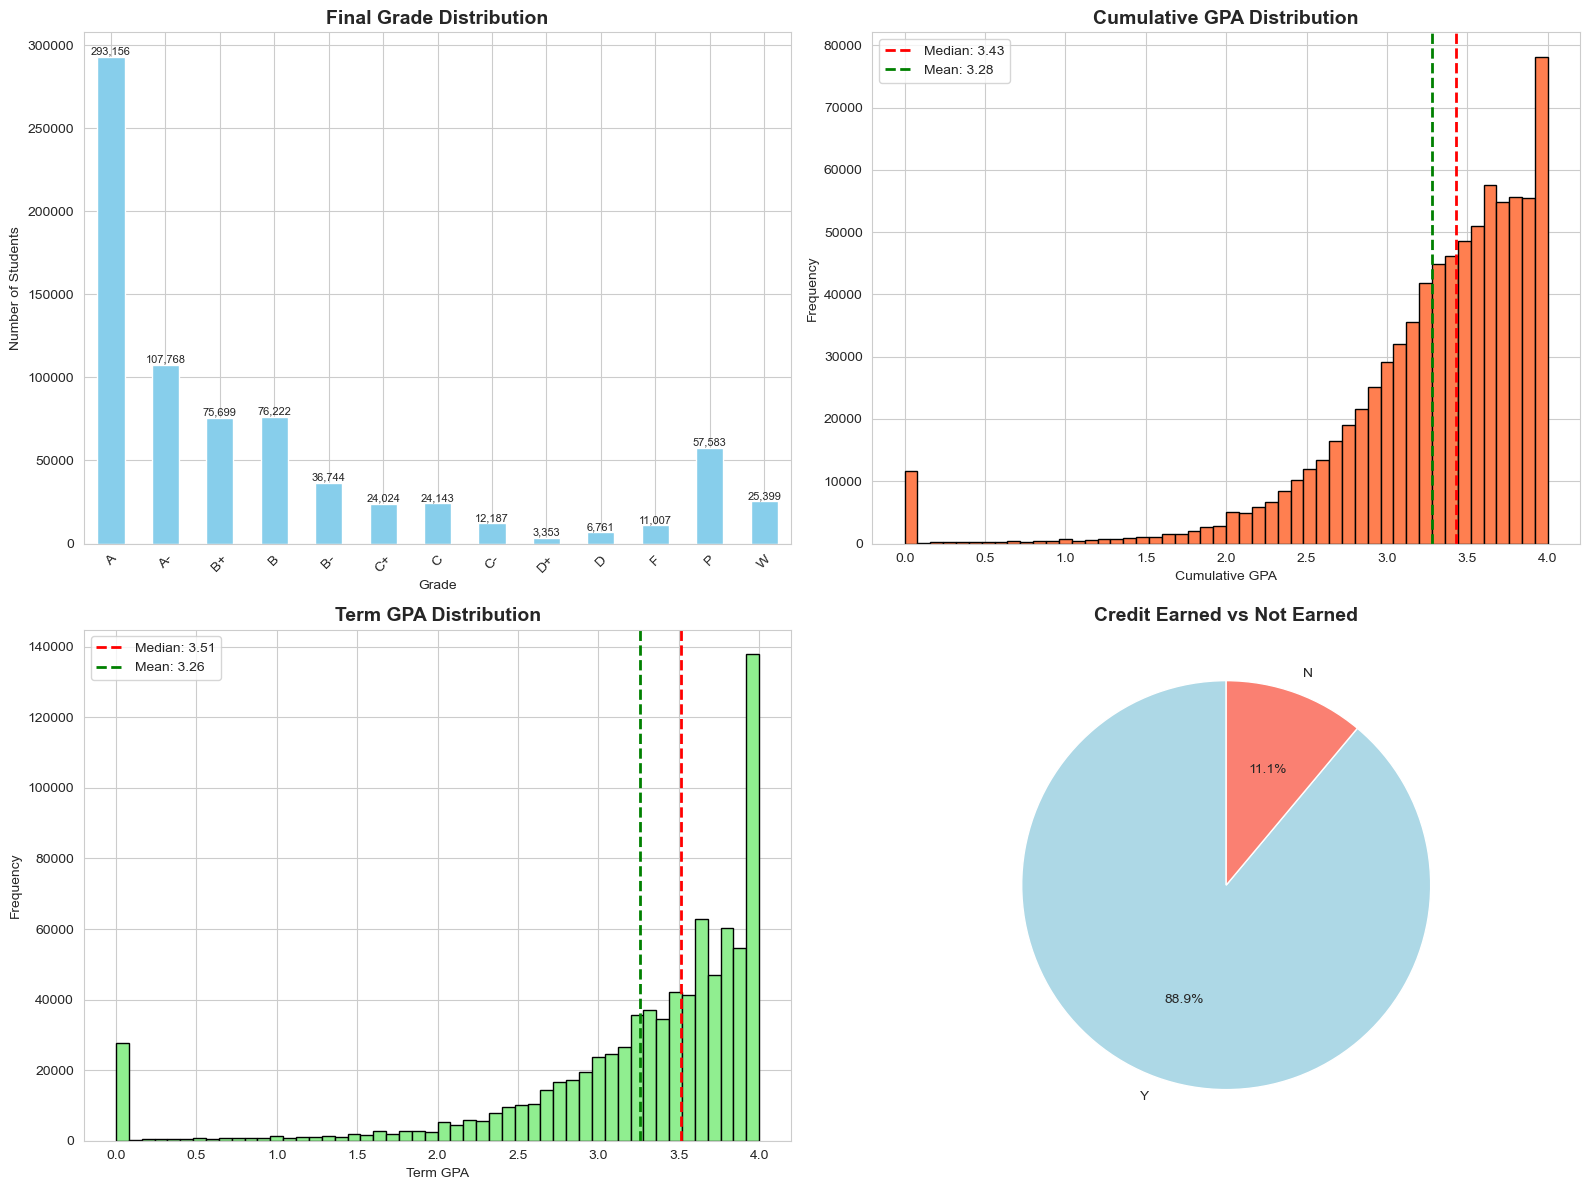

In [60]:
# Visualize academic performance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Grade distribution
grade_order = ['A', 'A-', 'B+', 'B', 'B-', 'C+', 'C', 'C-', 'D+', 'D', 'D-', 'F', 'P', 'W']
grade_counts = df['FinalGrade'].value_counts()
grade_counts_ordered = grade_counts.reindex([g for g in grade_order if g in grade_counts.index])

ax1 = axes[0, 0]
grade_counts_ordered.plot(kind='bar', ax=ax1, color='skyblue')
ax1.set_title('Final Grade Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Grade')
ax1.set_ylabel('Number of Students')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(grade_counts_ordered):
    if pd.notna(v):
        ax1.text(i, v + 100, f'{v:,}', ha='center', va='bottom', fontsize=8)

# 2. Cumulative GPA distribution
ax2 = axes[0, 1]
df['CummulativeGPA'].dropna().hist(bins=50, ax=ax2, color='coral', edgecolor='black')
ax2.set_title('Cumulative GPA Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Cumulative GPA')
ax2.set_ylabel('Frequency')
ax2.axvline(df['CummulativeGPA'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {df["CummulativeGPA"].median():.2f}')
ax2.axvline(df['CummulativeGPA'].mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {df["CummulativeGPA"].mean():.2f}')
ax2.legend()

# 3. Term GPA distribution
ax3 = axes[1, 0]
df['TermGPA'].dropna().hist(bins=50, ax=ax3, color='lightgreen', edgecolor='black')
ax3.set_title('Term GPA Distribution', fontsize=14, fontweight='bold')
ax3.set_xlabel('Term GPA')
ax3.set_ylabel('Frequency')
ax3.axvline(df['TermGPA'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {df["TermGPA"].median():.2f}')
ax3.axvline(df['TermGPA'].mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {df["TermGPA"].mean():.2f}')
ax3.legend()

# 4. Credit earned vs not earned
credit_earned = df['EarnCredit'].value_counts()
ax4 = axes[1, 1]
credit_earned.plot(kind='pie', ax=ax4, autopct='%1.1f%%', colors=['lightblue', 'salmon'], startangle=90)
ax4.set_title('Credit Earned vs Not Earned', fontsize=14, fontweight='bold')
ax4.set_ylabel('')

plt.tight_layout()
plt.show()

### GPA Trends Over Time

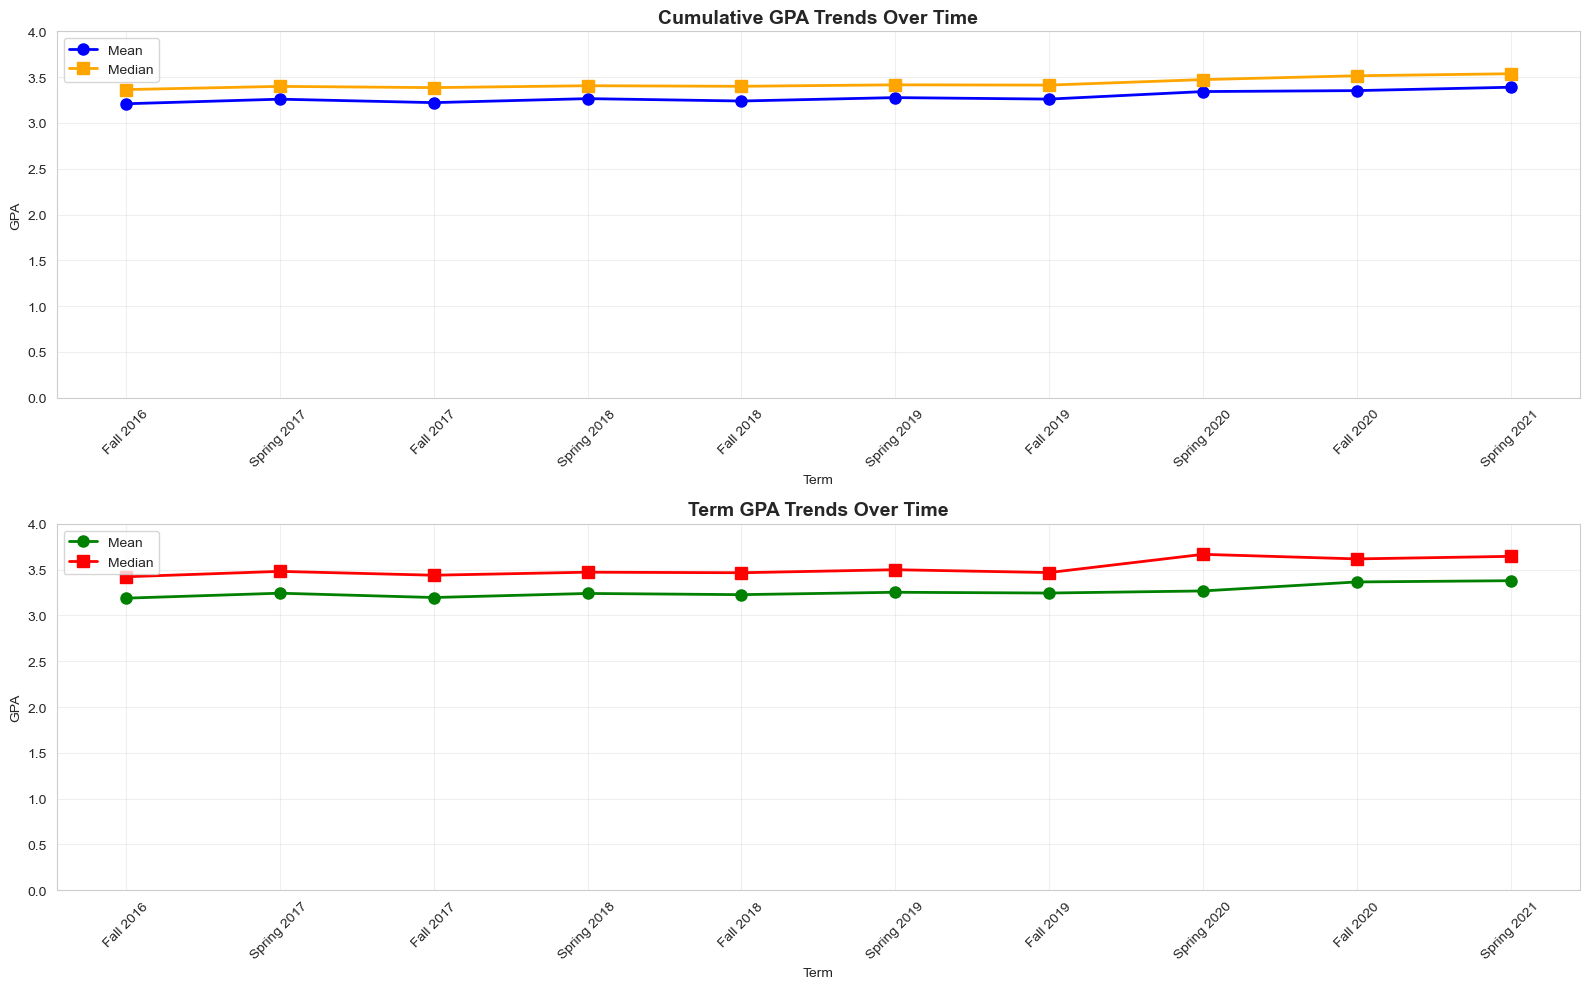


GPA Statistics by Term:
            CummulativeGPA           TermGPA       
                      mean  median      mean median
Term_Label                                         
Fall 2016         3.209156  3.3640  3.188457  3.422
Spring 2017       3.259318  3.3990  3.242693  3.481
Fall 2017         3.221583  3.3855  3.195519  3.439
Spring 2018       3.265293  3.4060  3.239937  3.472
Fall 2018         3.239250  3.4000  3.226811  3.466
Spring 2019       3.276555  3.4160  3.252860  3.499
Fall 2019         3.260037  3.4130  3.244422  3.468
Spring 2020       3.342438  3.4730  3.267324  3.667
Fall 2020         3.352864  3.5150  3.365569  3.617
Spring 2021       3.389667  3.5370  3.379207  3.645


In [61]:
# GPA trends over time
gpa_by_term = df.groupby('Term_Label').agg({
    'CummulativeGPA': ['mean', 'median'],
    'TermGPA': ['mean', 'median']
}).reindex(term_labels_ordered)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 1. Cumulative GPA
ax1 = axes[0]
ax1.plot(range(len(gpa_by_term)), gpa_by_term[('CummulativeGPA', 'mean')], 
         marker='o', linewidth=2, markersize=8, label='Mean', color='blue')
ax1.plot(range(len(gpa_by_term)), gpa_by_term[('CummulativeGPA', 'median')], 
         marker='s', linewidth=2, markersize=8, label='Median', color='orange')
ax1.set_title('Cumulative GPA Trends Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Term')
ax1.set_ylabel('GPA')
ax1.set_xticks(range(len(gpa_by_term)))
ax1.set_xticklabels(gpa_by_term.index, rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 4])

# 2. Term GPA
ax2 = axes[1]
ax2.plot(range(len(gpa_by_term)), gpa_by_term[('TermGPA', 'mean')], 
         marker='o', linewidth=2, markersize=8, label='Mean', color='green')
ax2.plot(range(len(gpa_by_term)), gpa_by_term[('TermGPA', 'median')], 
         marker='s', linewidth=2, markersize=8, label='Median', color='red')
ax2.set_title('Term GPA Trends Over Time', fontsize=14, fontweight='bold')
ax2.set_xlabel('Term')
ax2.set_ylabel('GPA')
ax2.set_xticks(range(len(gpa_by_term)))
ax2.set_xticklabels(gpa_by_term.index, rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 4])

plt.tight_layout()
plt.show()

print("\nGPA Statistics by Term:")
print(gpa_by_term)

### Performance by Academic Level

GPA Statistics by Academic Level:
                        CummulativeGPA               TermGPA              
                                  mean median    std    mean median    std
Academic_Level                                                            
Freshman                         3.090  3.277  0.799   3.083  3.330  0.872
Graduate                         3.728  3.845  0.433   3.514  3.876  0.998
Junior                           3.303  3.399  0.522   3.315  3.503  0.725
Post-Bacc Undergraduate          3.478  3.625  0.547   3.489  3.668  0.680
Professional Year 1              3.079  3.318  0.980   2.940  3.333  1.229
Professional Year 2              3.006  3.325  1.054   2.927  3.487  1.356
Professional Year 3              2.786  3.329  1.325   2.611  3.522  1.655
Professional Year 4              0.888  0.000  1.504   0.853  0.000  1.557
Senior                           3.351  3.435  0.466   3.397  3.600  0.680
Sophomore                        3.286  3.392  0.541   3.286  3.46

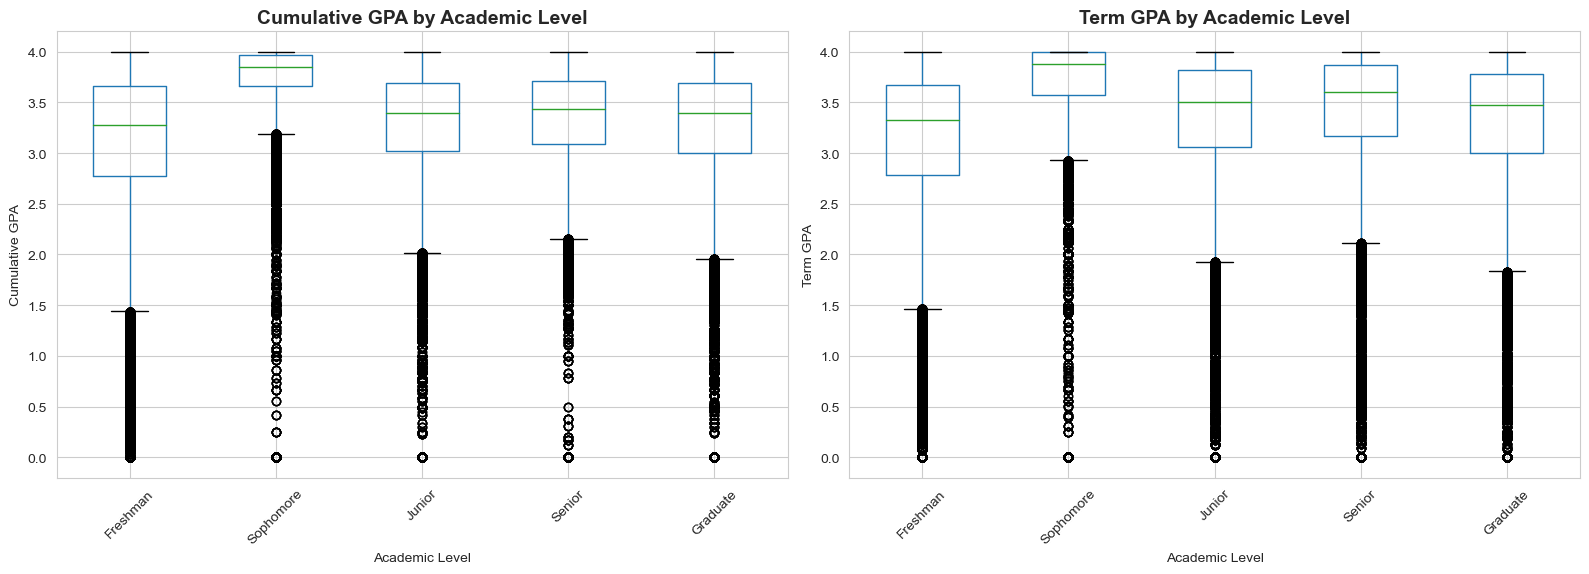

In [62]:
# GPA by academic level
gpa_by_level = df.groupby('Academic_Level').agg({
    'CummulativeGPA': ['mean', 'median', 'std'],
    'TermGPA': ['mean', 'median', 'std']
}).round(3)

print("GPA Statistics by Academic Level:")
print(gpa_by_level)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot for cumulative GPA
ax1 = axes[0]
level_order = ['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate']
level_order = [l for l in level_order if l in df['Academic_Level'].unique()]
df_filtered = df[df['Academic_Level'].isin(level_order)]
df_filtered.boxplot(column='CummulativeGPA', by='Academic_Level', ax=ax1, 
                     positions=range(len(level_order)))
ax1.set_title('Cumulative GPA by Academic Level', fontsize=14, fontweight='bold')
ax1.set_xlabel('Academic Level')
ax1.set_ylabel('Cumulative GPA')
ax1.set_xticklabels(level_order, rotation=45)
plt.sca(ax1)
plt.xticks(range(len(level_order)), level_order, rotation=45)

# Box plot for term GPA
ax2 = axes[1]
df_filtered.boxplot(column='TermGPA', by='Academic_Level', ax=ax2,
                     positions=range(len(level_order)))
ax2.set_title('Term GPA by Academic Level', fontsize=14, fontweight='bold')
ax2.set_xlabel('Academic Level')
ax2.set_ylabel('Term GPA')
ax2.set_xticklabels(level_order, rotation=45)
plt.sca(ax2)
plt.xticks(range(len(level_order)), level_order, rotation=45)

plt.suptitle('')  # Remove auto-generated title
plt.tight_layout()
plt.show()

## 6. Course Characteristics Analysis

In [63]:
# Course characteristics
print("Writing Intensive Courses:")
print(df['WritingIntensive'].value_counts())
print(f"Percentage: {(df['WritingIntensive']=='Y').sum() / len(df) * 100:.2f}%")
print("\n" + "="*60)

print("\nExperiential Learning Courses:")
print(df['ExperientialLearning'].value_counts())
print(f"Percentage: {(df['ExperientialLearning']=='Y').sum() / len(df) * 100:.2f}%")
print("\n" + "="*60)

print("\nHonors Courses:")
print(df['Honors'].value_counts())
print(f"Percentage: {(df['Honors']=='Y').sum() / len(df) * 100:.2f}%")
print("\n" + "="*60)

print("\nBusiness Honors Courses:")
print(df['BusinessHonors'].value_counts())
print(f"Percentage: {(df['BusinessHonors']=='Y').sum() / len(df) * 100:.2f}%")
print("\n" + "="*60)

print("\nCORE Area Courses:")
print(df['CORE_Area'].value_counts())

Writing Intensive Courses:
WritingIntensive
Y    25169
Name: count, dtype: int64
Percentage: 3.10%


Experiential Learning Courses:
ExperientialLearning
Y    29548
Name: count, dtype: int64
Percentage: 3.64%


Honors Courses:
Honors
Y    11979
Name: count, dtype: int64
Percentage: 1.48%


Business Honors Courses:
BusinessHonors
Y    2914
Name: count, dtype: int64
Percentage: 0.36%


CORE Area Courses:
CORE_Area
N    616517
Y    194630
Name: count, dtype: int64


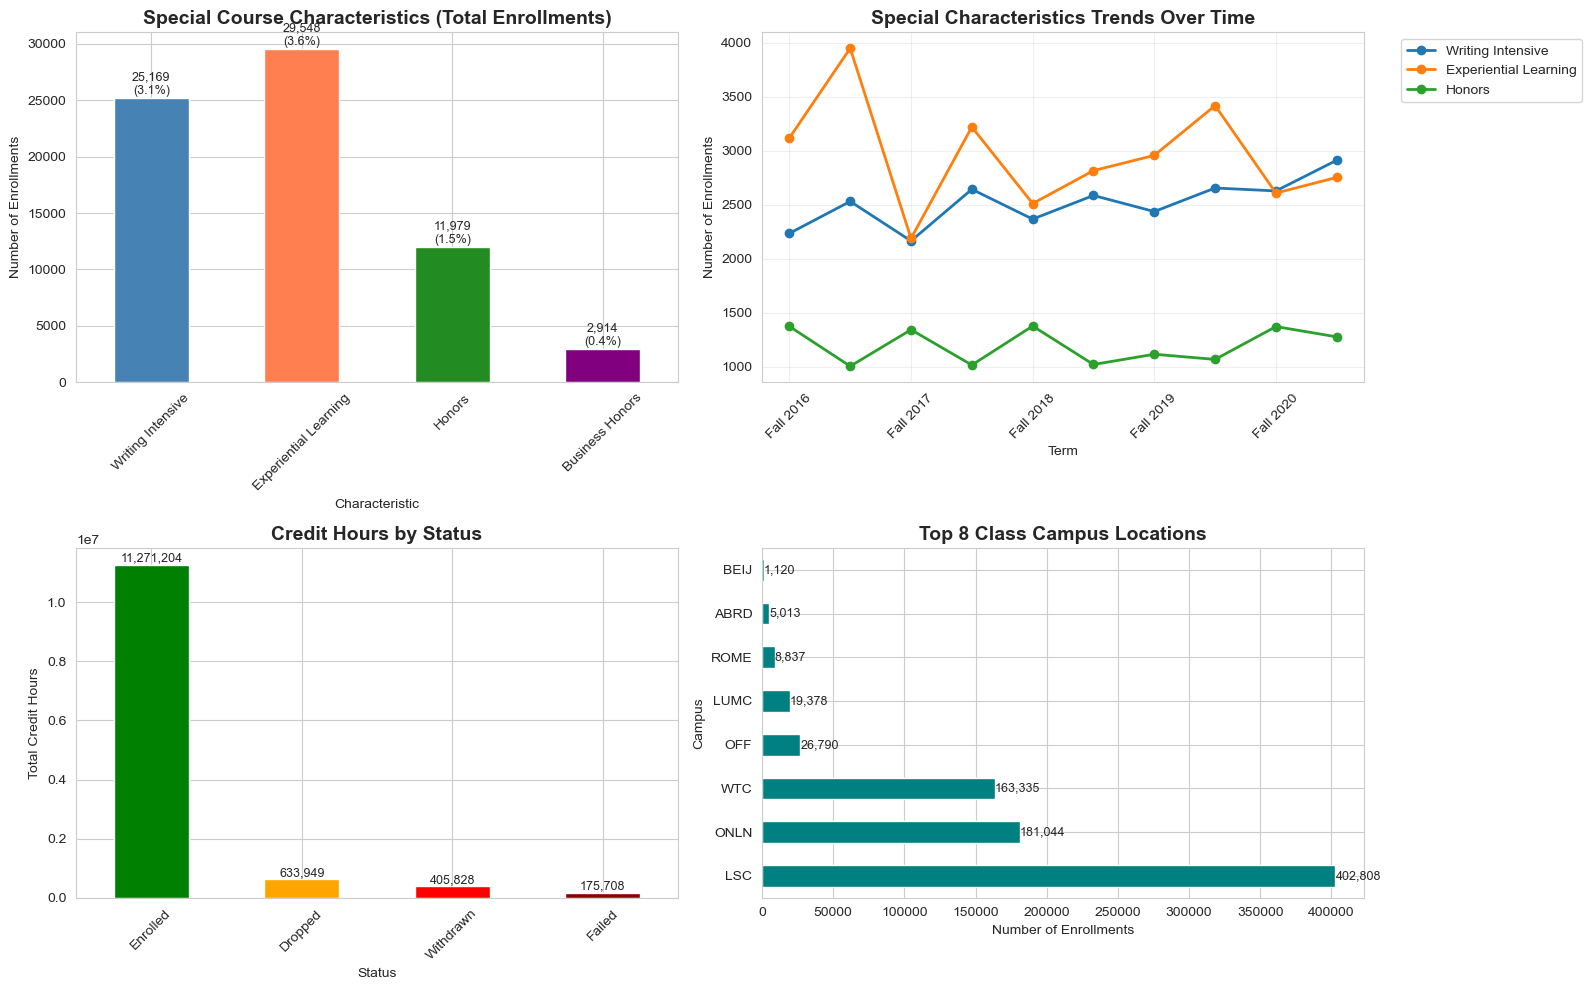

In [64]:
# Visualize course characteristics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Calculate percentages
characteristics = {
    'Writing Intensive': (df['WritingIntensive']=='Y').sum(),
    'Experiential Learning': (df['ExperientialLearning']=='Y').sum(),
    'Honors': (df['Honors']=='Y').sum(),
    'Business Honors': (df['BusinessHonors']=='Y').sum()
}

# 1. Overall course characteristics
ax1 = axes[0, 0]
char_series = pd.Series(characteristics)
char_series.plot(kind='bar', ax=ax1, color=['steelblue', 'coral', 'forestgreen', 'purple'])
ax1.set_title('Special Course Characteristics (Total Enrollments)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Characteristic')
ax1.set_ylabel('Number of Enrollments')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(char_series):
    ax1.text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

# 2. Course characteristics over time
ax2 = axes[0, 1]
char_by_term = pd.DataFrame({
    'Writing Intensive': df[df['WritingIntensive']=='Y'].groupby('Term_Label').size(),
    'Experiential Learning': df[df['ExperientialLearning']=='Y'].groupby('Term_Label').size(),
    'Honors': df[df['Honors']=='Y'].groupby('Term_Label').size()
}).reindex(term_labels_ordered).fillna(0)

char_by_term.plot(kind='line', ax=ax2, marker='o', linewidth=2, markersize=6)
ax2.set_title('Special Characteristics Trends Over Time', fontsize=14, fontweight='bold')
ax2.set_xlabel('Term')
ax2.set_ylabel('Number of Enrollments')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

# 3. Enrolled vs dropped vs withdrawn
ax3 = axes[1, 0]
enrolled_hours = df['EnrolledHours'].sum()
dropped_hours = df['DroppedHours'].sum()
withdrawn_hours = df['WithdrawnHours'].sum()
failed_hours = df['FailedHours'].sum()

hours_data = pd.Series({
    'Enrolled': enrolled_hours,
    'Dropped': dropped_hours,
    'Withdrawn': withdrawn_hours,
    'Failed': failed_hours
})
hours_data.plot(kind='bar', ax=ax3, color=['green', 'orange', 'red', 'darkred'])
ax3.set_title('Credit Hours by Status', fontsize=14, fontweight='bold')
ax3.set_xlabel('Status')
ax3.set_ylabel('Total Credit Hours')
ax3.tick_params(axis='x', rotation=45)
for i, v in enumerate(hours_data):
    if pd.notna(v):
        ax3.text(i, v + 1000, f'{v:,.0f}', ha='center', va='bottom', fontsize=9)

# 4. Class campus distribution
campus_dist = df['ClassCampus'].value_counts().head(8)
ax4 = axes[1, 1]
campus_dist.plot(kind='barh', ax=ax4, color='teal')
ax4.set_title('Top 8 Class Campus Locations', fontsize=14, fontweight='bold')
ax4.set_xlabel('Number of Enrollments')
ax4.set_ylabel('Campus')
for i, v in enumerate(campus_dist):
    ax4.text(v + 200, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Majors and Programs Analysis

In [65]:
# Most popular majors (Active_Plan_List)
print("Top 20 Most Popular Majors/Plans:")
top_majors = df['Active_Plan_List'].value_counts().head(20)
print(top_majors)
print("\n" + "="*60)

# Most popular minors/subplans
print("\nTop 20 Most Popular Minors/Subplans:")
# Filter out empty values
subplans = df[df['Active_Subplan_List'].notna() & (df['Active_Subplan_List'] != '')]
top_subplans = subplans['Active_Subplan_List'].value_counts().head(20)
print(top_subplans)

Top 20 Most Popular Majors/Plans:
Active_Plan_List
BIOL-BS       12922
PSYC-BS        6578
MD-MD          3920
UNDG-UGRD      3912
UND -BA        2987
LAW -JD        2947
NURS-BSN       2897
MBA -MBA       2536
FINC-BBA       2100
MARK-BBA       1969
MBA1-MBA       1926
COMP-BS        1860
BIOC-BS        1853
PPHS-PBAC      1727
PLSC-BA        1695
ADPR-BASOC     1577
NRMC-BS        1549
NRCB-BS        1465
CHEM-BS        1369
FRSC-BS        1363
Name: count, dtype: int64


Top 20 Most Popular Minors/Subplans:
Active_Subplan_List
//                        4019
INTG-TRCK                 1644
FMPR-TRCK                 1446
INTG-TRK                   599
ADVT-TRCK                  549
SUMM-UNDG                  535
ADCP-TRKBS, MICP-SPCBS     492
//   //                    347
// HIST-SECE               312
ADCP-SWKT, MICP-SPEC       268
FINC-MBA D                 240
// SENG-SECE               235
PBRL-TRCK                  208
// FMPR-TRCK               184
MICP-SPCBS, SSWP-TRKBS     172

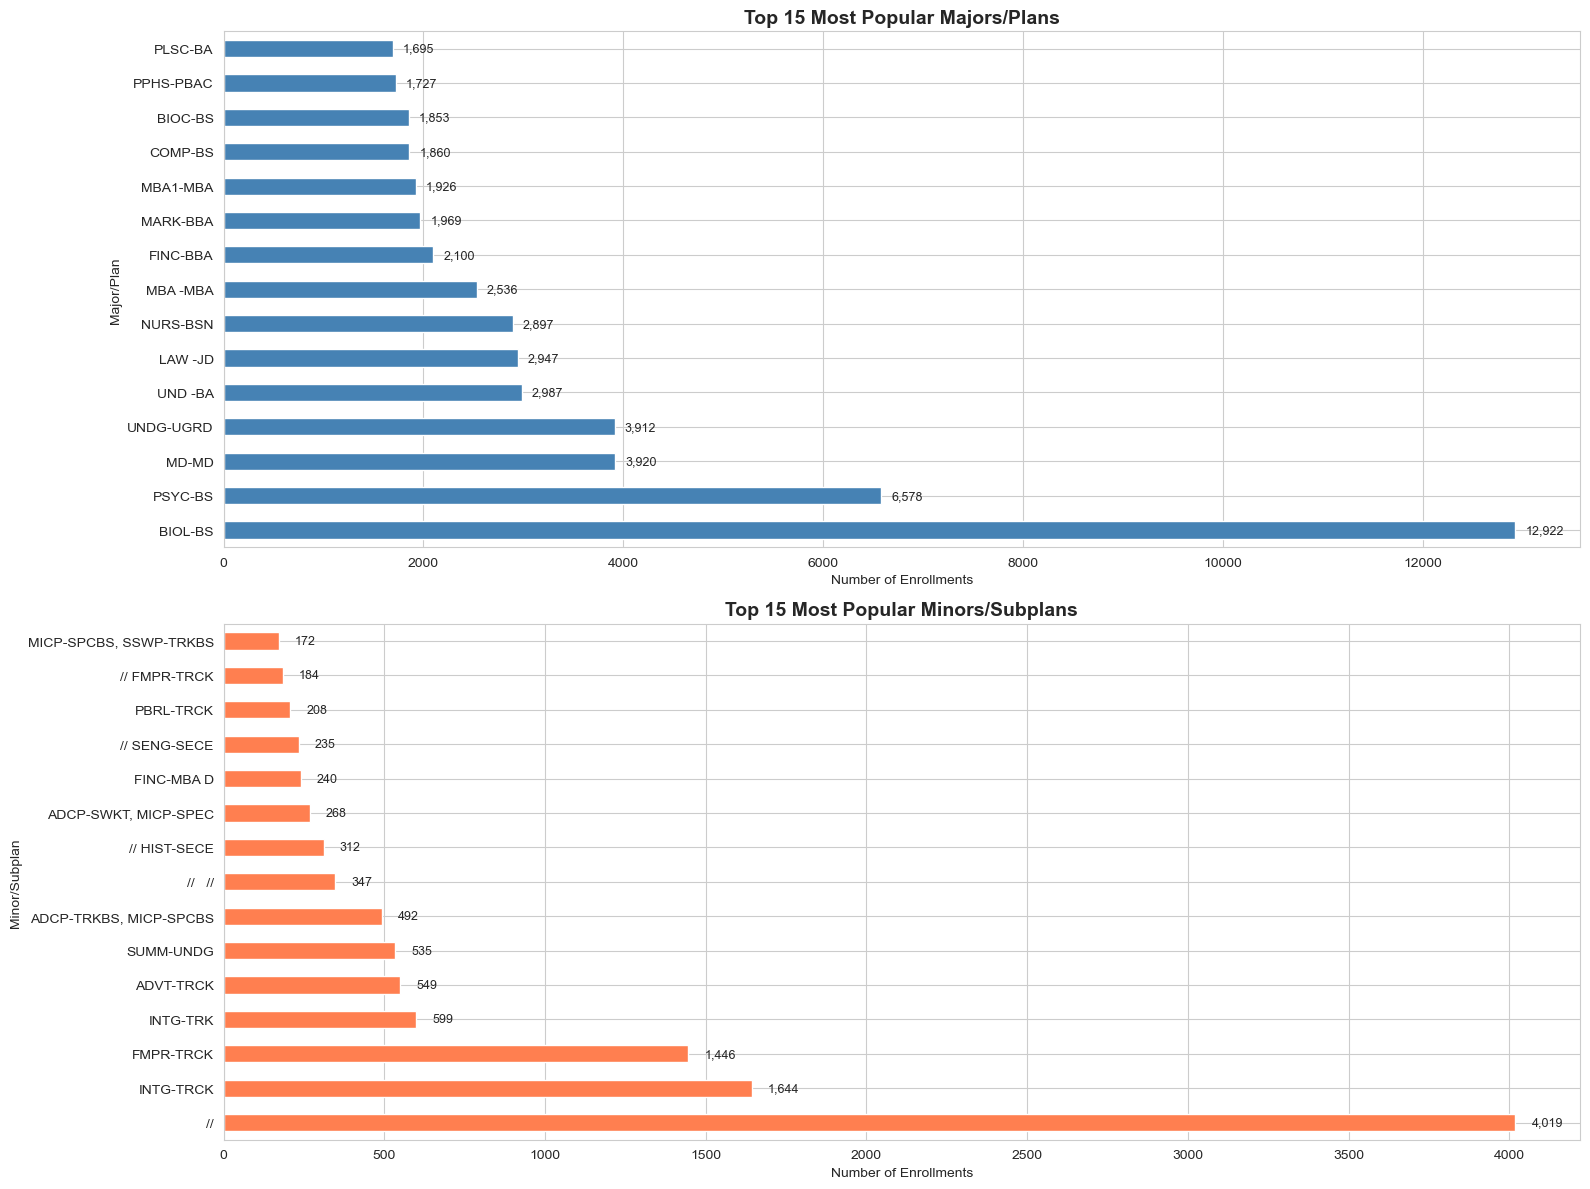

In [66]:
# Visualize majors and programs
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# 1. Top 15 majors
top_majors_15 = df['Active_Plan_List'].value_counts().head(15)
ax1 = axes[0]
top_majors_15.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Top 15 Most Popular Majors/Plans', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Enrollments')
ax1.set_ylabel('Major/Plan')
for i, v in enumerate(top_majors_15):
    ax1.text(v + 100, i, f'{v:,}', va='center', fontsize=9)

# 2. Top 15 minors/subplans
top_subplans_15 = subplans['Active_Subplan_List'].value_counts().head(15)
ax2 = axes[1]
top_subplans_15.plot(kind='barh', ax=ax2, color='coral')
ax2.set_title('Top 15 Most Popular Minors/Subplans', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Enrollments')
ax2.set_ylabel('Minor/Subplan')
for i, v in enumerate(top_subplans_15):
    ax2.text(v + 50, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Instructor and Location Analysis

In [67]:
# Building usage
print("Top 15 Most Used Buildings:")
building_usage = df['MeetingBuilding'].value_counts().head(15)
print(building_usage)
print("\n" + "="*60)

# Campus distribution
print("\nCampus Distribution:")
campus_usage = df['ClassCampus'].value_counts()
print(campus_usage)

Top 15 Most Used Buildings:
MeetingBuilding
ONLINE    157500
MUND      102528
CLC        98795
CUNEO      68377
DU         57375
CC         35098
LSB        31164
SCHR       30239
FH         28037
SULL       20502
CS         17219
JFMH       13259
SOC        11023
IC          9977
IES         9273
Name: count, dtype: int64


Campus Distribution:
ClassCampus
LSC     402808
ONLN    181044
WTC     163335
OFF      26790
LUMC     19378
ROME      8837
ABRD      5013
BEIJ      1120
VIET      1102
CART       961
CUNE       477
STJS       264
WOOD        18
Name: count, dtype: int64


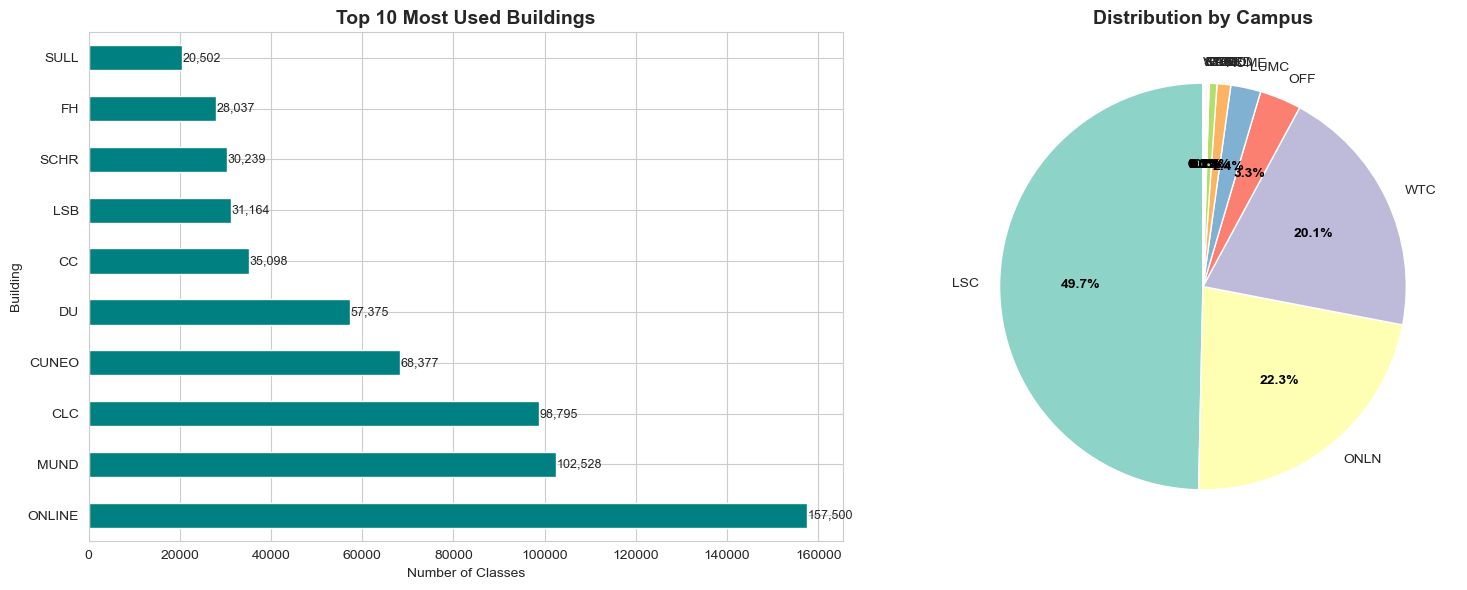

In [68]:
# Visualize location data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Top buildings
building_top10 = df['MeetingBuilding'].value_counts().head(10)
ax1 = axes[0]
building_top10.plot(kind='barh', ax=ax1, color='teal')
ax1.set_title('Top 10 Most Used Buildings', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Classes')
ax1.set_ylabel('Building')
for i, v in enumerate(building_top10):
    ax1.text(v + 100, i, f'{v:,}', va='center', fontsize=9)

# 2. Campus distribution pie chart
campus_counts = df['ClassCampus'].value_counts()
ax2 = axes[1]
colors = sns.color_palette("Set3", len(campus_counts))
wedges, texts, autotexts = ax2.pie(campus_counts, labels=campus_counts.index, 
                                     autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Distribution by Campus', fontsize=14, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

### Online vs In-Person Trends Over Time

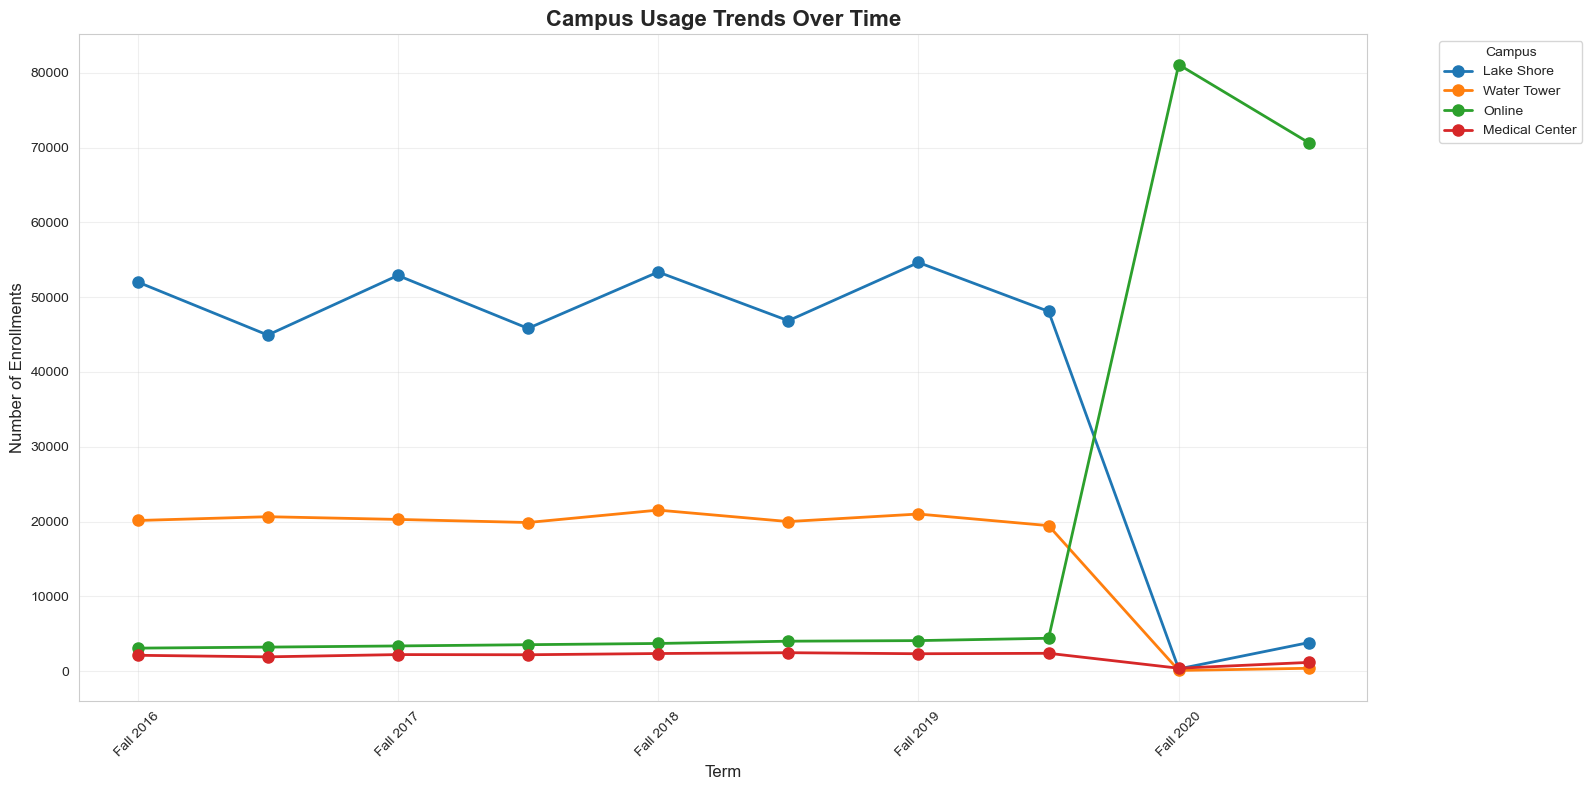


Campus usage by term:
ClassCampus    LSC    WTC   ONLN  LUMC
Term_Label                            
Fall 2016    52041  20135   3062  2105
Spring 2017  44942  20642   3199  1896
Fall 2017    52913  20279   3355  2199
Spring 2018  45833  19867   3522  2176
Fall 2018    53374  21526   3686  2341
Spring 2019  46859  19993   3990  2451
Fall 2019    54647  21000   4069  2312
Spring 2020  48109  19450   4383  2371
Fall 2020      285     75  81115   374
Spring 2021   3805    368  70663  1153


In [69]:
# Track online vs in-person over time
campus_by_term = df.groupby(['Term_Label', 'ClassCampus']).size().unstack(fill_value=0)
campus_by_term = campus_by_term.reindex(term_labels_ordered)

# Focus on main campuses
main_campuses = ['LSC', 'WTC', 'ONLN', 'LUMC']
campus_by_term_main = campus_by_term[[c for c in main_campuses if c in campus_by_term.columns]]

fig, ax = plt.subplots(figsize=(16, 8))
campus_by_term_main.plot(kind='line', ax=ax, marker='o', linewidth=2, markersize=8)
ax.set_title('Campus Usage Trends Over Time', fontsize=16, fontweight='bold')
ax.set_xlabel('Term', fontsize=12)
ax.set_ylabel('Number of Enrollments', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Campus', labels=['Lake Shore', 'Water Tower', 'Online', 'Medical Center'], 
          bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCampus usage by term:")
print(campus_by_term_main)

## 9. Overall Summary Statistics

In [ ]:
# Comprehensive summary
print("="*80)
print("COMPREHENSIVE DATA SUMMARY (Fall 2016 - Spring 2021)")
print("="*80)

print(f"\nOVERALL STATISTICS")
print(f"   Total enrollment records: {len(df):,}")
print(f"   Unique students: {df['LID'].nunique():,}")
print(f"   Unique courses offered: {df['Course'].nunique():,}")
print(f"   Unique subjects: {df['Subject'].nunique()}")
print(f"   Terms covered: {df['Term'].nunique()}")
print(f"   Date range: {df['Year'].min()} - {df['Year'].max()}")

print(f"\nACADEMIC STANDING")
for level, count in df['Academic_Level'].value_counts().head(5).items():
    pct = count / len(df) * 100
    print(f"   {level}: {count:,} enrollments ({pct:.1f}%)")

print(f"\nCOURSE ENROLLMENT")
print(f"   Average courses per student per term: {(len(df) / df.groupby(['Term', 'LID']).ngroups):.2f}")
print(f"   Most popular subject: {df['Subject'].mode()[0]} ({df['Subject'].value_counts().iloc[0]:,} enrollments)")
print(f"   Most popular course: {df['Course'].mode()[0]} ({df['Course'].value_counts().iloc[0]:,} enrollments)")

print(f"\nACADEMIC PERFORMANCE")
print(f"   Average cumulative GPA: {df['CummulativeGPA'].mean():.3f}")
print(f"   Median cumulative GPA: {df['CummulativeGPA'].median():.3f}")
print(f"   Average term GPA: {df['TermGPA'].mean():.3f}")
print(f"   Median term GPA: {df['TermGPA'].median():.3f}")
print(f"   Most common grade: {df['FinalGrade'].mode()[0]}")
grade_success = df[df['FinalGrade'].isin(['A', 'A-', 'B+', 'B', 'B-', 'C+', 'C'])].shape[0]
print(f"   Success rate (C or better): {(grade_success / len(df[df['FinalGrade'].notna()]) * 100):.1f}%")

print(f"\nCOURSE CHARACTERISTICS")
print(f"   Writing intensive: {(df['WritingIntensive']=='Y').sum():,} ({(df['WritingIntensive']=='Y').sum()/len(df)*100:.1f}%)")
print(f"   Experiential learning: {(df['ExperientialLearning']=='Y').sum():,} ({(df['ExperientialLearning']=='Y').sum()/len(df)*100:.1f}%)")
print(f"   Honors courses: {(df['Honors']=='Y').sum():,} ({(df['Honors']=='Y').sum()/len(df)*100:.1f}%)")

print(f"\nLOCATION DISTRIBUTION")
print(f"   Most used campus: {df['ClassCampus'].mode()[0]}")
print(f"   Most used building: {df['MeetingBuilding'].mode()[0]}")
print(f"   Online enrollments: {df[df['ClassCampus']=='ONLN'].shape[0]:,} ({df[df['ClassCampus']=='ONLN'].shape[0]/len(df)*100:.1f}%)")

print(f"\nENROLLMENT PATTERNS")
print(f"   Peak enrollment term: {df.groupby('Term_Label').size().idxmax()}")
print(f"   Peak enrollment count: {df.groupby('Term_Label').size().max():,}")
print(f"   Average term enrollment: {df.groupby('Term_Label').size().mean():,.0f}")

print(f"\nTOP PROGRAMS")
for i, (major, count) in enumerate(df['Active_Plan_List'].value_counts().head(5).items(), 1):
    print(f"   {i}. {major}: {count:,} enrollments")

print("\n" + "="*80)

COMPREHENSIVE DATA SUMMARY (Fall 2016 - Spring 2021)

OVERALL STATISTICS
   Total enrollment records: 811,147
   Unique students: 45,820
   Unique courses offered: 3,861
   Unique subjects: 152
   Terms covered: 10
   Date range: 2016 - 2021

STUDENT DEMOGRAPHICS
   Gender breakdown:
      No Information Provided: 45,820 (100.0%)
   Top ethnicity: No Information Provided
   Top state: No Information Provided

ACADEMIC STANDING
   Freshman: 192,192 enrollments (23.7%)
   Senior: 171,788 enrollments (21.2%)
   Sophomore: 154,120 enrollments (19.0%)
   Junior: 148,484 enrollments (18.3%)
   Graduate: 89,228 enrollments (11.0%)

COURSE ENROLLMENT
   Average courses per student per term: 4.74
   Most popular subject: BIOL (56,563 enrollments)
   Most popular course: UNIV 101 (13,227 enrollments)

ACADEMIC PERFORMANCE
   Average cumulative GPA: 3.281
   Median cumulative GPA: 3.432
   Average term GPA: 3.260
   Median term GPA: 3.511
   Most common grade: A
   Success rate (C or better): 84.

## 10. Correlation Analysis

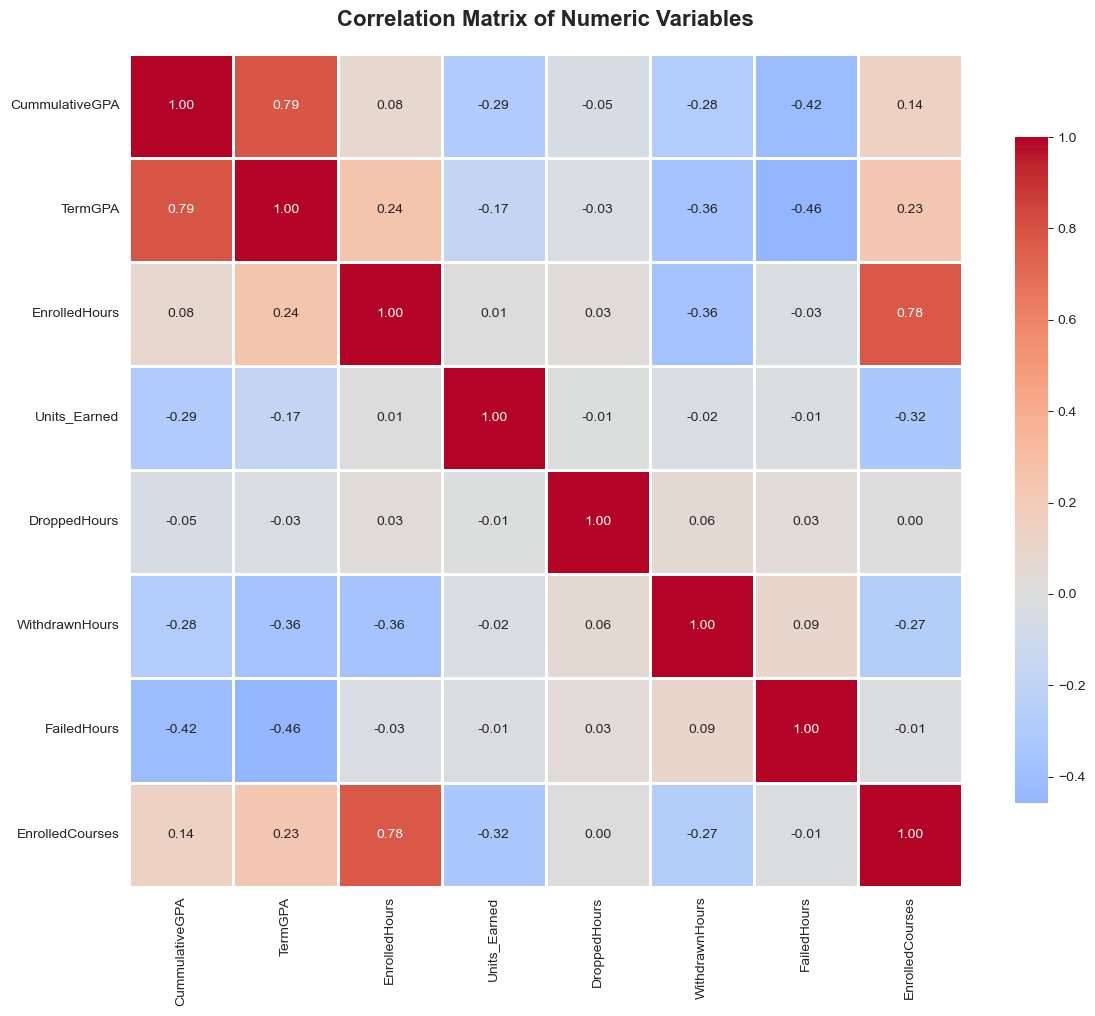


Key Correlations:
CummulativeGPA <-> TermGPA: 0.788
EnrolledHours <-> EnrolledCourses: 0.776


In [71]:
# Select numeric columns for correlation
numeric_cols = ['CummulativeGPA', 'TermGPA', 'EnrolledHours', 'Units_Earned', 
                'DroppedHours', 'WithdrawnHours', 'FailedHours', 'EnrolledCourses']

# Create correlation matrix
correlation_df = df[numeric_cols].corr()

# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix of Numeric Variables', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nKey Correlations:")
print("="*60)
# Find strong correlations (excluding diagonal)
for i in range(len(correlation_df.columns)):
    for j in range(i+1, len(correlation_df.columns)):
        corr_val = correlation_df.iloc[i, j]
        if abs(corr_val) > 0.5:
            print(f"{correlation_df.columns[i]} <-> {correlation_df.columns[j]}: {corr_val:.3f}")

## 11. Year-over-Year Comparisons

In [72]:
# Year-over-year analysis
yearly_stats = df.groupby('Year').agg({
    'LID': 'nunique',
    'Course': 'count',
    'CummulativeGPA': 'mean',
    'TermGPA': 'mean',
    'Units_Earned': 'sum',
    'DroppedHours': 'sum',
    'FailedHours': 'sum'
}).round(3)

yearly_stats.columns = ['Unique Students', 'Total Enrollments', 'Avg Cum GPA', 
                         'Avg Term GPA', 'Total Credits Earned', 'Total Dropped Hours', 
                         'Total Failed Hours']

print("Year-over-Year Statistics:")
print(yearly_stats)

# Calculate year-over-year growth rates
growth_rates = yearly_stats.pct_change() * 100
print("\n\nYear-over-Year Growth Rates (%):")
print(growth_rates.round(2))

Year-over-Year Statistics:
      Unique Students  Total Enrollments  Avg Cum GPA  Avg Term GPA  \
Year                                                                  
2016            17007              81275        3.209         3.188   
2017            22541             157254        3.239         3.218   
2018            22972             161554        3.251         3.233   
2019            23147             166390        3.268         3.248   
2020            22941             166436        3.348         3.318   
2021            16656              78238        3.390         3.379   

      Total Credits Earned  Total Dropped Hours  Total Failed Hours  
Year                                                                 
2016             211609.71              62826.0             19199.0  
2017             415542.27             134558.5             36444.0  
2018             426583.91             139662.5             38267.0  
2019             441262.06             134602.5       

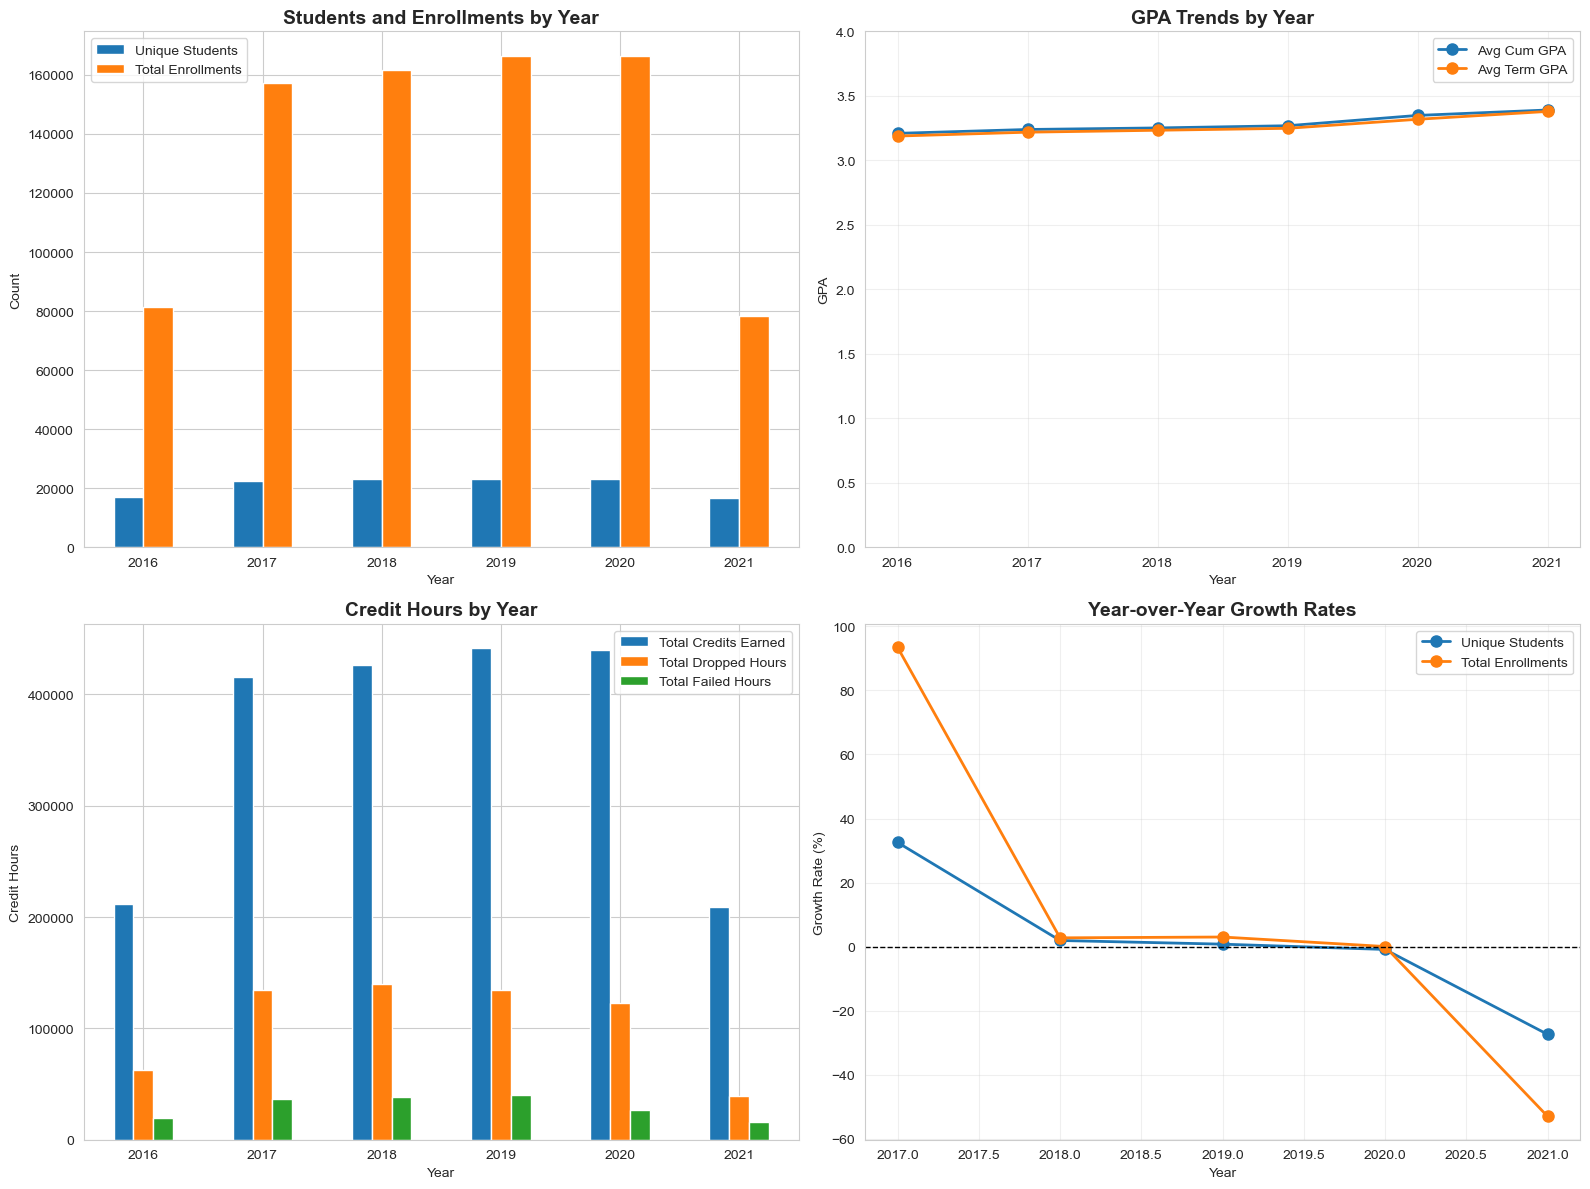

In [73]:
# Visualize year-over-year trends
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Enrollment trends
ax1 = axes[0, 0]
yearly_stats[['Unique Students', 'Total Enrollments']].plot(kind='bar', ax=ax1)
ax1.set_title('Students and Enrollments by Year', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)
ax1.legend()

# 2. GPA trends
ax2 = axes[0, 1]
yearly_stats[['Avg Cum GPA', 'Avg Term GPA']].plot(kind='line', ax=ax2, marker='o', linewidth=2, markersize=8)
ax2.set_title('GPA Trends by Year', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('GPA')
ax2.set_ylim([0, 4])
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Credits earned vs dropped/failed
ax3 = axes[1, 0]
yearly_stats[['Total Credits Earned', 'Total Dropped Hours', 'Total Failed Hours']].plot(kind='bar', ax=ax3)
ax3.set_title('Credit Hours by Year', fontsize=14, fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Credit Hours')
ax3.tick_params(axis='x', rotation=0)
ax3.legend()

# 4. Enrollment growth rate
ax4 = axes[1, 1]
growth_rates[['Unique Students', 'Total Enrollments']].plot(kind='line', ax=ax4, marker='o', linewidth=2, markersize=8)
ax4.set_title('Year-over-Year Growth Rates', fontsize=14, fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Growth Rate (%)')
ax4.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Semester-by-Semester Detailed Breakdown

In [ ]:
# Detailed semester analysis
semester_stats = df.groupby('Term_Label').agg({
    'LID': 'nunique',
    'Course': ['count', 'nunique'],
    'Subject': 'nunique',
    'CummulativeGPA': ['mean', 'median', 'std'],
    'TermGPA': ['mean', 'median', 'std'],
    'Units_Earned': 'sum',
    'EnrolledHours': 'sum',
    'DroppedHours': 'sum',
    'FailedHours': 'sum'
}).round(3)

semester_stats.columns = ['_'.join(col).strip('_') for col in semester_stats.columns]
semester_stats = semester_stats.reindex(term_labels_ordered)

print("Detailed Semester-by-Semester Statistics:")
print(semester_stats)
"""
# Save to CSV for further analysis
semester_stats.to_csv('semester_statistics.csv')
print("\nSemester statistics saved to 'semester_statistics.csv'")"""

Detailed Semester-by-Semester Statistics:
             LID_nunique  Course_count  Course_nunique  Subject_nunique  \
Term_Label                                                                
Fall 2016          17007         81275            1797              132   
Spring 2017        15883         74214            1863              134   
Fall 2017          17637         83040            1811              136   
Spring 2018        16190         75367            1901              132   
Fall 2018          18076         86187            1833              134   
Spring 2019        16668         78549            1937              136   
Fall 2019          18255         87841            1843              140   
Spring 2020        16819         79868            1943              137   
Fall 2020          18008         86568            1781              134   
Spring 2021        16656         78238            1862              133   

             CummulativeGPA_mean  CummulativeGPA_median  

In [75]:
"""# Directory containing the TSV files
input_dir = "OneDrive_1_1-22-2026"
output_file = "merged_student_enrollment.tsv"

# List to store DataFrames
dataframes = []

# Loop through all files in the directory
for file in os.listdir(input_dir):
    if file.endswith(".tsv"):
        file_path = os.path.join(input_dir, file)
        # Read the TSV file into a DataFrame
        df = pd.read_csv(file_path, sep="\t")
        dataframes.append(df)

# Concatenate all DataFrames
merged_df = pd.concat(dataframes, ignore_index=True)

# Save the merged DataFrame to a new TSV file
merged_df.to_csv(output_file, sep="\t", index=False)

print(f"All TSV files have been merged into {output_file}")"""

'# Directory containing the TSV files\ninput_dir = "OneDrive_1_1-22-2026"\noutput_file = "merged_student_enrollment.tsv"\n\n# List to store DataFrames\ndataframes = []\n\n# Loop through all files in the directory\nfor file in os.listdir(input_dir):\n    if file.endswith(".tsv"):\n        file_path = os.path.join(input_dir, file)\n        # Read the TSV file into a DataFrame\n        df = pd.read_csv(file_path, sep="\t")\n        dataframes.append(df)\n\n# Concatenate all DataFrames\nmerged_df = pd.concat(dataframes, ignore_index=True)\n\n# Save the merged DataFrame to a new TSV file\nmerged_df.to_csv(output_file, sep="\t", index=False)\n\nprint(f"All TSV files have been merged into {output_file}")'